#Starting

In [ ]:
!pip install gspread pandas numpy scikit-learn -q

In [ ]:
import gspread
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from google.colab import auth
from google.auth import default

# --- Autentikasi & koneksi ke Google Sheets ---
auth.authenticate_user()
creds, _ = default()
client = gspread.authorize(creds)

SPREADSHEET_ID = "1UwOc262c9qrrzZW5wDuR9zL430n1tEOVpbqX9HhYuSo"
spreadsheet = client.open_by_key(SPREADSHEET_ID)


def load_sheet(spreadsheet, sheet_name: str) -> pd.DataFrame:
    """Load satu worksheet dari Google Sheets jadi DataFrame, dengan log singkat."""
    worksheet = spreadsheet.worksheet(sheet_name)
    data = worksheet.get_all_records()
    df = pd.DataFrame(data)
    print(f"Sheet '{sheet_name}' berhasil di-load! Shape: {df.shape}")
    return df


# --- Load semua sheet yang dibutuhkan ---
df = load_sheet(spreadsheet, "raw_s1_status_objek")
df2 = load_sheet(spreadsheet, "raw_s2_posisi_objek")
df3 = load_sheet(spreadsheet, "raw_s3_status_global")

df.head()

Sheet 'raw_s1_status_objek' berhasil di-load! Shape: (4688, 17)
Sheet 'raw_s2_posisi_objek' berhasil di-load! Shape: (8104, 18)
Sheet 'raw_s3_status_global' berhasil di-load! Shape: (24923, 15)


,timestamp,session_id,scenario_id,mechanism_type,player_id,player_count,event_type,player_ping_ms,server_event_time,client_receive_time,object_id,object_type,action_player_id,server_object_status,client_object_status,server_spawn_time,client_spawn_receive_time
0,2026-06-02T01:35:56Z,eef8e482-b2ad-4530-b1ed-f3d30b872df0,1,chop,609644675,4,LogSpawned,71,1780364156,1780392961,pohon_155_7_-1,log,8599334150,spawned,visible,1780364156,1780392961
1,2026-06-02T01:35:56Z,eef8e482-b2ad-4530-b1ed-f3d30b872df0,1,chop,609644675,4,LogSpawned,71,1780364156,1780392961,pohon_155_7_-1,log,8599334150,spawned,visible,1780364156,1780392961
2,2026-06-02T01:35:56Z,eef8e482-b2ad-4530-b1ed-f3d30b872df0,1,chop,609644675,4,LogSpawned,71,1780364156,1780392961,pohon_155_7_-1,log,8599334150,spawned,visible,1780364156,1780392961
3,2026-06-02T01:35:56Z,eef8e482-b2ad-4530-b1ed-f3d30b872df0,1,chop,609644675,4,LogSpawned,71,1780364156,1780392961,pohon_155_7_-1,log,8599334150,spawned,visible,1780364156,1780392961
4,2026-06-02T01:35:56Z,eef8e482-b2ad-4530-b1ed-f3d30b872df0,1,chop,308262420,4,LogSpawned,71,1780364156,1780392955,pohon_155_7_-1,log,8599334150,spawned,visible,1780364156,1780392955


In [ ]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import seaborn
import sys

print(f"Python: {sys.version}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"sklearn: {sklearn.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"seaborn: {seaborn.__version__}")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
pandas: 2.2.2
numpy: 2.0.2
sklearn: 1.6.1
matplotlib: 3.10.0
seaborn: 0.13.2


#Validasi Data

In [ ]:
#cek kolom
print('df.columns.tolist():')
display(df.columns.tolist())

print('\ndf2.columns.tolist():')
display(df2.columns.tolist())

print('\ndf3.columns.tolist():')
display(df3.columns.tolist())

df.columns.tolist():


['timestamp',
 'session_id',
 'scenario_id',
 'mechanism_type',
 'player_id',
 'player_count',
 'event_type',
 'player_ping_ms',
 'server_event_time',
 'client_receive_time',
 'object_id',
 'object_type',
 'action_player_id',
 'server_object_status',
 'client_object_status',
 'server_spawn_time',
 'client_spawn_receive_time']


df2.columns.tolist():


['timestamp',
 'session_id',
 'scenario_id',
 'mechanism_type',
 'player_id',
 'player_count',
 'event_type',
 'player_ping_ms',
 'server_event_time',
 'client_receive_time',
 'object_id',
 'action_player_id',
 'server_pos_x',
 'server_pos_y',
 'server_pos_z',
 'client_pos_x',
 'client_pos_y',
 'client_pos_z']


df3.columns.tolist():


['timestamp',
 'session_id',
 'scenario_id',
 'mechanism_type',
 'player_id',
 'player_count',
 'event_type',
 'player_ping_ms',
 'server_event_time',
 'client_receive_time',
 'generator_id',
 'fuel_before',
 'fuel_after',
 'server_fuel_value',
 'client_fuel_value']

In [ ]:
#cek info
print('df.info():')
display(df.info())

print('\ndf2.info():')
display(df2.info())

print('\ndf3.info():')
display(df3.info())

df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4688 entries, 0 to 4687
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   timestamp                  4688 non-null   object
 1   session_id                 4688 non-null   object
 2   scenario_id                4688 non-null   int64 
 3   mechanism_type             4688 non-null   object
 4   player_id                  4688 non-null   int64 
 5   player_count               4688 non-null   int64 
 6   event_type                 4688 non-null   object
 7   player_ping_ms             4688 non-null   int64 
 8   server_event_time          4688 non-null   int64 
 9   client_receive_time        4688 non-null   int64 
 10  object_id                  4688 non-null   object
 11  object_type                4688 non-null   object
 12  action_player_id           4688 non-null   int64 
 13  server_object_status       4688 non-null   object
 1

None


df2.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8104 entries, 0 to 8103
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   timestamp            8104 non-null   object
 1   session_id           8104 non-null   object
 2   scenario_id          8104 non-null   int64 
 3   mechanism_type       8104 non-null   object
 4   player_id            8104 non-null   int64 
 5   player_count         8104 non-null   int64 
 6   event_type           8104 non-null   object
 7   player_ping_ms       8104 non-null   int64 
 8   server_event_time    8104 non-null   int64 
 9   client_receive_time  8104 non-null   int64 
 10  object_id            8104 non-null   object
 11  action_player_id     8104 non-null   int64 
 12  server_pos_x         8104 non-null   int64 
 13  server_pos_y         8104 non-null   int64 
 14  server_pos_z         8104 non-null   int64 
 15  client_pos_x         8104 non-null   int64

None


df3.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24923 entries, 0 to 24922
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   timestamp            24923 non-null  object
 1   session_id           24923 non-null  object
 2   scenario_id          24923 non-null  int64 
 3   mechanism_type       24923 non-null  object
 4   player_id            24923 non-null  object
 5   player_count         24923 non-null  int64 
 6   event_type           24923 non-null  object
 7   player_ping_ms       24923 non-null  int64 
 8   server_event_time    24923 non-null  int64 
 9   client_receive_time  24923 non-null  object
 10  generator_id         24923 non-null  object
 11  fuel_before          24923 non-null  int64 
 12  fuel_after           24923 non-null  int64 
 13  server_fuel_value    24923 non-null  int64 
 14  client_fuel_value    24923 non-null  object
dtypes: int64(7), object(8)
memory usage: 2.9

None

In [ ]:
#jumlah kolom per sesi
print('df["session_id"].value_counts():')
display(df["session_id"].value_counts())

print('\ndf2["session_id"].value_counts():')
display(df2["session_id"].value_counts())

print('\ndf3["session_id"].value_counts():')
display(df3["session_id"].value_counts())

df["session_id"].value_counts():


,count
session_id,
05445fdc-8c37-48b2-9041-984689832837,768
7cb1c5fa-3061-46c6-a349-b6dea5c3eebb,752
e3f4a891-0523-4d11-8696-ed60ae671e08,752
0171ba77-0275-47a4-9870-edda700b7e3b,688
eef8e482-b2ad-4530-b1ed-f3d30b872df0,624
e79a8603-919a-4778-aec4-b73639ed93fa,280
4684d646-a479-49ed-8c4e-a40480495459,176
fb4b7122-a6f2-4459-b694-5a08890f076c,160
68344811-4c29-4538-aa70-6103bc727002,136



df2["session_id"].value_counts():


,count
session_id,
e3f4a891-0523-4d11-8696-ed60ae671e08,1611
eef8e482-b2ad-4530-b1ed-f3d30b872df0,1188
0171ba77-0275-47a4-9870-edda700b7e3b,1184
05445fdc-8c37-48b2-9041-984689832837,1072
7cb1c5fa-3061-46c6-a349-b6dea5c3eebb,1020
e79a8603-919a-4778-aec4-b73639ed93fa,610
4684d646-a479-49ed-8c4e-a40480495459,346
fb4b7122-a6f2-4459-b694-5a08890f076c,302
68344811-4c29-4538-aa70-6103bc727002,289



df3["session_id"].value_counts():


,count
session_id,
05445fdc-8c37-48b2-9041-984689832837,3480
0171ba77-0275-47a4-9870-edda700b7e3b,3471
eef8e482-b2ad-4530-b1ed-f3d30b872df0,3303
7cb1c5fa-3061-46c6-a349-b6dea5c3eebb,3032
e3f4a891-0523-4d11-8696-ed60ae671e08,2909
4684d646-a479-49ed-8c4e-a40480495459,1850
68344811-4c29-4538-aa70-6103bc727002,1565
fb4b7122-a6f2-4459-b694-5a08890f076c,1557
e79a8603-919a-4778-aec4-b73639ed93fa,1513


In [ ]:
#jumlah sesi
print('df["scenario_id"].value_counts():')
display(df["scenario_id"].value_counts())

print('\ndf2["scenario_id"].value_counts():')
display(df2["scenario_id"].value_counts())

print('\ndf3["scenario_id"].value_counts():')
display(df3["scenario_id"].value_counts())

df["scenario_id"].value_counts():


,count
scenario_id,
1,4688



df2["scenario_id"].value_counts():


,count
scenario_id,
2,8104



df3["scenario_id"].value_counts():


,count
scenario_id,
3,24923


In [ ]:
#jumlah data per id player
print('df["player_id"].value_counts():')
display(df["player_id"].value_counts())

print('\ndf2["player_id"].value_counts():')
display(df2["player_id"].value_counts())

print('\ndf3["player_id"].value_counts():')
display(df3["player_id"].value_counts())

df["player_id"].value_counts():


,count
player_id,
609644675,1236
8599334150,1176
5325351196,1152
308262420,1124



df2["player_id"].value_counts():


,count
player_id,
609644675,2169
8599334150,2031
308262420,1957
5325351196,1947



df3["player_id"].value_counts():


,count
player_id,
8599334150,6875
609644675,6535
308262420,6333
5325351196,5136
server,44


In [ ]:
#cek kolom nill/kosong
print('df.isnull().sum():')
display(df.isnull().sum())

print('\ndf2.isnull().sum():')
display(df2.isnull().sum())

print('\ndf3.isnull().sum():')
display(df3.isnull().sum())

df.isnull().sum():


,0
timestamp,0
session_id,0
scenario_id,0
mechanism_type,0
player_id,0
player_count,0
event_type,0
player_ping_ms,0
server_event_time,0
client_receive_time,0



df2.isnull().sum():


,0
timestamp,0
session_id,0
scenario_id,0
mechanism_type,0
player_id,0
player_count,0
event_type,0
player_ping_ms,0
server_event_time,0
client_receive_time,0



df3.isnull().sum():


,0
timestamp,0
session_id,0
scenario_id,0
mechanism_type,0
player_id,0
player_count,0
event_type,0
player_ping_ms,0
server_event_time,0
client_receive_time,0


In [ ]:
import pandas as pd

nan_count = df2[['client_pos_x', 'client_pos_y', 'client_pos_z']].isnull().sum()
print("Yang NaN:")
print(nan_count)

zero_count = (df2[['client_pos_x', 'client_pos_y', 'client_pos_z']] == 0).sum()
print("\nYang bernilai 0:")
print(zero_count)

all_zero = df2[(df2['client_pos_x'] == 0) & (df2['client_pos_y'] == 0) & (df2['client_pos_z'] == 0)]
print(f"\nBaris yang client_pos x, y, z semuanya 0: {len(all_zero)}")

Yang NaN:
client_pos_x    0
client_pos_y    0
client_pos_z    0
dtype: int64

Yang bernilai 0:
client_pos_x    1352
client_pos_y    1354
client_pos_z    1352
dtype: int64

Baris yang client_pos x, y, z semuanya 0: 1352


Asumsi:

Kerena yang kebanyakan di drag adalah 'bahan bakar' generator, seperti fuel dan log, sehingga client pos nya 0. client mencari keberadaan 'bahan bakar' itu, tetapi server/generator telah 'destroyed' bahan bakar itu, yang menyebabnyan posnya tidak ditemukan atau 0. Mengganggu? tidak tau. tapi itu cukup bisa berpengaruh walau kecil.

Tindakan : Jangan hapus dan jadikan percobaan olah ketika selesai melakukan cleaning data

#Cleaning Data

In [ ]:
#hapus sesi yang gagal
selected_sessions_df = [
    "e3f4a891-0523-4d11-8696-ed60ae671e08",
    "eef8e482-b2ad-4530-b1ed-f3d30b872df0",
    "0171ba77-0275-47a4-9870-edda700b7e3b",
    "05445fdc-8c37-48b2-9041-984689832837",
    "7cb1c5fa-3061-46c6-a349-b6dea5c3eebb",
    "e79a8603-919a-4778-aec4-b73639ed93fa",
    "4684d646-a479-49ed-8c4e-a40480495459",
    "fb4b7122-a6f2-4459-b694-5a08890f076c",
    "68344811-4c29-4538-aa70-6103bc727002",
    "53fb412e-fdc7-4c86-acd0-f1e83fa21c22",
]
df = df[df["session_id"].isin(selected_sessions_df)]

# df2 dan df3 - otomatis top 10
top10_df2 = df2["session_id"].value_counts().head(10).index
df2 = df2[df2["session_id"].isin(top10_df2)]

top10_df3 = df3["session_id"].value_counts().head(10).index
df3 = df3[df3["session_id"].isin(top10_df3)]

# Verifikasi
print(f"df:  {df['session_id'].nunique()} session, {len(df)} baris")
print(f"df2: {df2['session_id'].nunique()} session, {len(df2)} baris")
print(f"df3: {df3['session_id'].nunique()} session, {len(df3)} baris")

df:  10 session, 4456 baris
df2: 10 session, 7852 baris
df3: 10 session, 24144 baris


In [ ]:
#jumlah kolom per sesi
print('df["session_id"].value_counts():')
display(df["session_id"].value_counts())

print('\ndf2["session_id"].value_counts():')
display(df2["session_id"].value_counts())

print('\ndf3["session_id"].value_counts():')
display(df3["session_id"].value_counts())

df["session_id"].value_counts():


,count
session_id,
05445fdc-8c37-48b2-9041-984689832837,768
7cb1c5fa-3061-46c6-a349-b6dea5c3eebb,752
e3f4a891-0523-4d11-8696-ed60ae671e08,752
0171ba77-0275-47a4-9870-edda700b7e3b,688
eef8e482-b2ad-4530-b1ed-f3d30b872df0,624
e79a8603-919a-4778-aec4-b73639ed93fa,280
4684d646-a479-49ed-8c4e-a40480495459,176
fb4b7122-a6f2-4459-b694-5a08890f076c,160
68344811-4c29-4538-aa70-6103bc727002,136



df2["session_id"].value_counts():


,count
session_id,
e3f4a891-0523-4d11-8696-ed60ae671e08,1611
eef8e482-b2ad-4530-b1ed-f3d30b872df0,1188
0171ba77-0275-47a4-9870-edda700b7e3b,1184
05445fdc-8c37-48b2-9041-984689832837,1072
7cb1c5fa-3061-46c6-a349-b6dea5c3eebb,1020
e79a8603-919a-4778-aec4-b73639ed93fa,610
4684d646-a479-49ed-8c4e-a40480495459,346
fb4b7122-a6f2-4459-b694-5a08890f076c,302
68344811-4c29-4538-aa70-6103bc727002,289



df3["session_id"].value_counts():


,count
session_id,
05445fdc-8c37-48b2-9041-984689832837,3480
0171ba77-0275-47a4-9870-edda700b7e3b,3471
eef8e482-b2ad-4530-b1ed-f3d30b872df0,3303
7cb1c5fa-3061-46c6-a349-b6dea5c3eebb,3032
e3f4a891-0523-4d11-8696-ed60ae671e08,2909
4684d646-a479-49ed-8c4e-a40480495459,1850
68344811-4c29-4538-aa70-6103bc727002,1565
fb4b7122-a6f2-4459-b694-5a08890f076c,1557
e79a8603-919a-4778-aec4-b73639ed93fa,1513


In [ ]:
#Asumsi diatas dibersihkan dari sesi yang tidak digunakan
import pandas as pd

nan_count = df2[['client_pos_x', 'client_pos_y', 'client_pos_z']].isnull().sum()
print("Yang NaN:")
print(nan_count)

zero_count = (df2[['client_pos_x', 'client_pos_y', 'client_pos_z']] == 0).sum()
print("\nYang bernilai 0:")
print(zero_count)

all_zero = df2[(df2['client_pos_x'] == 0) & (df2['client_pos_y'] == 0) & (df2['client_pos_z'] == 0)]
print(f"\nBaris yang client_pos x, y, z semuanya 0: {len(all_zero)}")

Yang NaN:
client_pos_x    0
client_pos_y    0
client_pos_z    0
dtype: int64

Yang bernilai 0:
client_pos_x    1321
client_pos_y    1323
client_pos_z    1321
dtype: int64

Baris yang client_pos x, y, z semuanya 0: 1321


In [ ]:
# Lihat dulu berapa banyak
print(df3[df3["player_id"] == "server"].shape[0])

# Filter hanya baris yang player_id-nya 'server'
df3_server = df3[df3["player_id"] == "server"]
print(df3_server.head())

35
                 timestamp                            session_id  scenario_id  \
0     2026-06-02T01:34:51Z  eef8e482-b2ad-4530-b1ed-f3d30b872df0            3   
1     2026-06-02T01:34:52Z  eef8e482-b2ad-4530-b1ed-f3d30b872df0            3   
3299  2026-06-02T01:45:39Z  eef8e482-b2ad-4530-b1ed-f3d30b872df0            3   
3300  2026-06-02T01:45:40Z  eef8e482-b2ad-4530-b1ed-f3d30b872df0            3   
3301  2026-06-02T01:45:42Z  eef8e482-b2ad-4530-b1ed-f3d30b872df0            3   

     mechanism_type player_id  player_count           event_type  \
0         generator    server             0  GeneratorFuelChange   
1         generator    server             0  GeneratorFuelChange   
3299      generator    server             0  GeneratorFuelChange   
3300      generator    server             0  GeneratorFuelChange   
3301      generator    server             0  GeneratorFuelChange   

      player_ping_ms  server_event_time client_receive_time generator_id  \
0                 -1     

In [ ]:
df3 = df3[df3["player_id"] != "server"]

In [ ]:
print(df3[df3["player_id"] == "server"].shape[0])

df3_server = df3[df3["player_id"] == "server"]
print(df3_server.head())

0
Empty DataFrame
Columns: [timestamp, session_id, scenario_id, mechanism_type, player_id, player_count, event_type, player_ping_ms, server_event_time, client_receive_time, generator_id, fuel_before, fuel_after, server_fuel_value, client_fuel_value]
Index: []


In [ ]:
#cek data yang memiliki player count 0, 1 dan 3
print(df[df["player_count"].isin([0, 1, 3])].shape[0])

0


In [ ]:
print(df2[df2["player_count"].isin([0, 1, 3])].shape[0])

5


In [ ]:
print(df3[df3["player_count"].isin([0, 1, 3])].shape[0])

446


In [ ]:
#Bersihkan data yang memiliki player count 0, 1, dan 3
df2 = df2[~df2["player_count"].isin([0, 1, 3])]

In [ ]:
df3 = df3[~df3["player_count"].isin([0, 1, 3])]

In [ ]:
print(df2[df2["player_count"].isin([0, 1, 3])].shape[0])

0


In [ ]:
print(df3[df3["player_count"].isin([0, 1, 3])].shape[0])

0


In [ ]:
#cek info
print('df.info():')
display(df.info())

print('\ndf2.info():')
display(df2.info())

print('\ndf3.info():')
display(df3.info())

df.info():
<class 'pandas.core.frame.DataFrame'>
Index: 4456 entries, 0 to 4687
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   timestamp                  4456 non-null   object
 1   session_id                 4456 non-null   object
 2   scenario_id                4456 non-null   int64 
 3   mechanism_type             4456 non-null   object
 4   player_id                  4456 non-null   int64 
 5   player_count               4456 non-null   int64 
 6   event_type                 4456 non-null   object
 7   player_ping_ms             4456 non-null   int64 
 8   server_event_time          4456 non-null   int64 
 9   client_receive_time        4456 non-null   int64 
 10  object_id                  4456 non-null   object
 11  object_type                4456 non-null   object
 12  action_player_id           4456 non-null   int64 
 13  server_object_status       4456 non-null   object
 14  cl

None


df2.info():
<class 'pandas.core.frame.DataFrame'>
Index: 7847 entries, 0 to 8103
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   timestamp            7847 non-null   object
 1   session_id           7847 non-null   object
 2   scenario_id          7847 non-null   int64 
 3   mechanism_type       7847 non-null   object
 4   player_id            7847 non-null   int64 
 5   player_count         7847 non-null   int64 
 6   event_type           7847 non-null   object
 7   player_ping_ms       7847 non-null   int64 
 8   server_event_time    7847 non-null   int64 
 9   client_receive_time  7847 non-null   int64 
 10  object_id            7847 non-null   object
 11  action_player_id     7847 non-null   int64 
 12  server_pos_x         7847 non-null   int64 
 13  server_pos_y         7847 non-null   int64 
 14  server_pos_z         7847 non-null   int64 
 15  client_pos_x         7847 non-null   int64 
 16

None


df3.info():
<class 'pandas.core.frame.DataFrame'>
Index: 23663 entries, 2 to 24921
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   timestamp            23663 non-null  object
 1   session_id           23663 non-null  object
 2   scenario_id          23663 non-null  int64 
 3   mechanism_type       23663 non-null  object
 4   player_id            23663 non-null  object
 5   player_count         23663 non-null  int64 
 6   event_type           23663 non-null  object
 7   player_ping_ms       23663 non-null  int64 
 8   server_event_time    23663 non-null  int64 
 9   client_receive_time  23663 non-null  object
 10  generator_id         23663 non-null  object
 11  fuel_before          23663 non-null  int64 
 12  fuel_after           23663 non-null  int64 
 13  server_fuel_value    23663 non-null  int64 
 14  client_fuel_value    23663 non-null  object
dtypes: int64(7), object(8)
memory usage: 2.9+ MB


None

Hasil dari pembersihan data:

1. tidak ada missing value dan data duplikat
2. player count dengan 0, 1 dan 3 dibersihkan karena tidak relevan dengan penelitian (mekanisme 2 player dan 4 player saja)
3. player_id dengan value "server" dibersihkan karena tidak relevan dengan penelitian (menyebabkan tidak masuknya client recieve time)

noted : untuk scenario 2 yang memiliki client post 0 tidak dihapus terlebih dahulu, karena kolom client_recieve_time terisi, hanya saja saya perlu mencari bukti bahwa asumsi saya benar atau ada alasan lain. Tindakan selanjutnya mengenai itu akan di putuskan setelah diketahui hasil dari clustering

#Eksplorasi Data

In [ ]:
import pandas as pd

baris_yang_dicek = [0, 10, 50, 100, 500]

for idx in baris_yang_dicek:
    row = df.iloc[idx]

    server_time = float(row["server_event_time"])
    client_time = float(row["client_receive_time"])

    selisih = client_time - server_time

    print(f"Baris {idx}")
    print(f"Server : {server_time}")
    print(f"Client : {client_time}")
    print(f"Selisih: {selisih}")
    print("-" * 50)

Baris 0
Server : 1780364156.0
Client : 1780392961.0
Selisih: 28805.0
--------------------------------------------------
Baris 10
Server : 1780364156.0
Client : 1780392956.0
Selisih: 28800.0
--------------------------------------------------
Baris 50
Server : 1780364165.0
Client : 1780392964.0
Selisih: 28799.0
--------------------------------------------------
Baris 100
Server : 1780364181.0
Client : 1780392980.0
Selisih: 28799.0
--------------------------------------------------
Baris 500
Server : 1780364589.0
Client : 1780393388.0
Selisih: 28799.0
--------------------------------------------------


Ditemukan selisih sebesar kurang lebih 28800 dari waktu server mengirim dan client menerima.

Asumsi:
Roblox (tepatnya perintah coding 'tick()') Unix Epoch untuk server nya yang dimana mereka menggunakan UTC 0, sedangkan penelitian dilakukan di Indonesia tepatnya di WITA yaitu UTC +8. 8 jam sama dengan 28800 detik.

In [ ]:
import pandas as pd

df["selisih"] = (
    df["client_receive_time"].astype(float)
    - df["server_event_time"].astype(float)
)

print(df["selisih"].describe())

count     4456.000000
mean     28800.725314
std          2.543617
min      28798.000000
25%      28799.000000
50%      28800.000000
75%      28804.000000
max      28806.000000
Name: selisih, dtype: float64


In [ ]:
df["delay_koreksi"] = (
    df["client_receive_time"]
    - df["server_event_time"]
    - 28800
)

print(df["delay_koreksi"].describe())

count    4456.000000
mean        0.725314
std         2.543617
min        -2.000000
25%        -1.000000
50%         0.000000
75%         4.000000
max         6.000000
Name: delay_koreksi, dtype: float64


In [ ]:
df["spawn_delay"] = (
    df["client_spawn_receive_time"] - df["server_spawn_time"] - 28800
)
print(df["spawn_delay"].describe())

count    4456.000000
mean        0.725314
std         2.543617
min        -2.000000
25%        -1.000000
50%         0.000000
75%         4.000000
max         6.000000
Name: spawn_delay, dtype: float64


delay_koreksi merepresentasikan selisih waktu antara pemrosesan event di server dan penerimaan di sisi client setelah dikontrol offset timezone.

In [ ]:
import pandas as pd

df2["selisih"] = (
    df2["client_receive_time"].astype(float)
    - df2["server_event_time"].astype(float)
)

print(df2["selisih"].describe())

count     7847.000000
mean     28800.697591
std          2.562584
min      28798.000000
25%      28799.000000
50%      28800.000000
75%      28804.000000
max      28806.000000
Name: selisih, dtype: float64


In [ ]:
df2["delay_koreksi"] = (
    df2["client_receive_time"]
    - df2["server_event_time"]
    - 28800
)

print(df2["delay_koreksi"].describe())

count    7847.000000
mean        0.697591
std         2.562584
min        -2.000000
25%        -1.000000
50%         0.000000
75%         4.000000
max         6.000000
Name: delay_koreksi, dtype: float64


In [ ]:
import pandas as pd

df3['client_receive_time'] = pd.to_numeric(df3['client_receive_time'], errors='coerce')
df3['server_event_time'] = pd.to_numeric(df3['server_event_time'], errors='coerce')

df3["selisih"] = (
    df3["client_receive_time"]
    - df3["server_event_time"]
)

print(df3["selisih"].describe())

count    23663.000000
mean     28800.661581
std          2.562629
min      28798.000000
25%      28799.000000
50%      28800.000000
75%      28804.000000
max      28806.000000
Name: selisih, dtype: float64


In [ ]:
df3["delay_koreksi"] = (
    df3["client_receive_time"]
    - df3["server_event_time"]
    - 28800
)

print(df3["delay_koreksi"].describe())

count    23663.000000
mean         0.661581
std          2.562629
min         -2.000000
25%         -1.000000
50%          0.000000
75%          4.000000
max          6.000000
Name: delay_koreksi, dtype: float64


Anehnya semua std nya itu rata2 2,5.
Asumsi:

- Apakah terpengaruh jaringan?
- Apakah terpengaruh dari codingan (bug codingan)?
- Apakah benar benar murni delay?

delay_koreksi range-nya sangat sempit — min -2, max 6, mayoritas di 0. Ini artinya hampir semua kondisi sinkronisasi terlihat "sama" secara nilai delay.

In [ ]:
df[["player_ping_ms","delay_koreksi"]].corr()

,player_ping_ms,delay_koreksi
player_ping_ms,1.000000,0.023004
delay_koreksi,0.023004,1.000000


In [ ]:
df2[["player_ping_ms","delay_koreksi"]].corr()

,player_ping_ms,delay_koreksi
player_ping_ms,1.000000,0.028837
delay_koreksi,0.028837,1.000000


In [ ]:
df3[["player_ping_ms","delay_koreksi"]].corr()

,player_ping_ms,delay_koreksi
player_ping_ms,1.000000,0.052474
delay_koreksi,0.052474,1.000000


Ping disini pengaruhnya sangat kecil terhadap delay_koreksi

In [ ]:
#Eksplorasi hal lain selain time count dari server dan client agar bisa di clusterisasi
import numpy as np

# Hitung pos_diff
df2["pos_diff"] = np.sqrt(
    (df2["server_pos_x"] - df2["client_pos_x"])**2 +
    (df2["server_pos_y"] - df2["client_pos_y"])**2 +
    (df2["server_pos_z"] - df2["client_pos_z"])**2
)

# Lihat distribusinya
df2["pos_diff"].describe()

# Lihat per event_type (DragStart vs DragStop)
df2.groupby("event_type")["pos_diff"].describe()

# Lihat per player_count (2 player vs 4 player)
df2.groupby("player_count")["pos_diff"].describe()

,count,mean,std,min,25%,50%,75%,max
player_count,,,,,,,,
2,1775.0,2893.155463,6175.406482,0.0,0.0,1.0,1098.912816,50144.409359
4,6072.0,3831.420805,6816.474729,0.0,0.0,42.0,5751.470160,50044.698720


untuk 2 player setengah dari semua event masih punya selisih kecil sekitar 1 unit — hampir sync tapi tidak sempurna. Baru 25% terbawah yang benar-benar 0. dan untuk 4 player setengah dari semua event sudah ada selisih 42 unit. Dan 25% sisanya bisa sampai 5751 unit.

In [ ]:
df3["server_fuel_value"] = pd.to_numeric(df3["server_fuel_value"], errors="coerce")
df3["client_fuel_value"] = pd.to_numeric(df3["client_fuel_value"], errors="coerce")

df3["fuel_diff"] = (df3["server_fuel_value"] - df3["client_fuel_value"]).abs()

# Cek ulang
df3[df3["fuel_diff"] > 0].groupby("player_count")["fuel_diff"].describe()

,count,mean,std,min,25%,50%,75%,max
player_count,,,,,,,,
2,187.0,656.930481,1107.268984,1.0,5.0,21.0,200.0,2697.0
4,1154.0,1091.330156,1556.980272,7.0,10.0,100.0,3537.0,3593.0


4 player jauh lebih rentan desync dibanding 2 player. Yang menarik di S3, saat desync terjadi nilainya sangat besar (sampai 3593) — artinya client bisa lihat nilai fuel yang sangat berbeda dari server.

In [ ]:
df3["server_fuel_value"] = pd.to_numeric(df3["server_fuel_value"], errors="coerce")
df3["client_fuel_value"] = pd.to_numeric(df3["client_fuel_value"], errors="coerce")

df3["fuel_diff"] = (df3["server_fuel_value"] - df3["client_fuel_value"]).abs()

# Cek ulang
df3[df3["fuel_diff"] > 0].groupby("player_count")["fuel_diff"].describe()

,count,mean,std,min,25%,50%,75%,max
player_count,,,,,,,,
2,187.0,656.930481,1107.268984,1.0,5.0,21.0,200.0,2697.0
4,1154.0,1091.330156,1556.980272,7.0,10.0,100.0,3537.0,3593.0


In [ ]:
# Lihat struktur unik S1
df.groupby(["session_id", "action_player_id", "server_spawn_time", "player_id"]).size().reset_index(name="count")

,session_id,action_player_id,server_spawn_time,player_id,count
0,0171ba77-0275-47a4-9870-edda700b7e3b,609644675,1780365710,308262420,4
1,0171ba77-0275-47a4-9870-edda700b7e3b,609644675,1780365710,609644675,4
2,0171ba77-0275-47a4-9870-edda700b7e3b,609644675,1780365710,5325351196,4
3,0171ba77-0275-47a4-9870-edda700b7e3b,609644675,1780365710,8599334150,4
4,0171ba77-0275-47a4-9870-edda700b7e3b,5325351196,1780365662,308262420,4
...,...,...,...,...,...
1109,fb4b7122-a6f2-4459-b694-5a08890f076c,609644675,1780370356,609644675,4
1110,fb4b7122-a6f2-4459-b694-5a08890f076c,609644675,1780370369,308262420,4
1111,fb4b7122-a6f2-4459-b694-5a08890f076c,609644675,1780370369,609644675,4
1112,fb4b7122-a6f2-4459-b694-5a08890f076c,609644675,1780370510,308262420,4


In [ ]:
# Variasi receive time antar client untuk event yang sama
df.groupby(["server_spawn_time"])["client_spawn_receive_time"].agg(["min","max","std","count"])

,min,max,std,count
server_spawn_time,,,,
1780364156,1780392955,1780392961,2.422120,16
1780364160,1780392958,1780392965,2.863564,16
1780364162,1780392960,1780392966,2.422120,16
1780364165,1780392964,1780392970,2.422120,16
1780364170,1780392968,1780392974,2.422120,16
...,...,...,...,...
1780371517,1780400317,1780400322,2.672612,8
1780371565,1780400365,1780400371,3.207135,8
1780371774,1780400574,1780400580,3.207135,8


In [ ]:
# Lihat kolom numerik yang tersedia
print("S1 numerik:")
print(df.select_dtypes(include='number').columns.tolist())

print("\nS2 numerik:")
print(df2.select_dtypes(include='number').columns.tolist())

print("\nS3 numerik:")
print(df3.select_dtypes(include='number').columns.tolist())

S1 numerik:
['scenario_id', 'player_id', 'player_count', 'player_ping_ms', 'server_event_time', 'client_receive_time', 'action_player_id', 'server_spawn_time', 'client_spawn_receive_time', 'selisih', 'delay_koreksi', 'spawn_delay']

S2 numerik:
['scenario_id', 'player_id', 'player_count', 'player_ping_ms', 'server_event_time', 'client_receive_time', 'action_player_id', 'server_pos_x', 'server_pos_y', 'server_pos_z', 'client_pos_x', 'client_pos_y', 'client_pos_z', 'selisih', 'delay_koreksi', 'pos_diff']

S3 numerik:
['scenario_id', 'player_count', 'player_ping_ms', 'server_event_time', 'client_receive_time', 'fuel_before', 'fuel_after', 'server_fuel_value', 'client_fuel_value', 'selisih', 'delay_koreksi', 'fuel_diff']


In [ ]:
#cek info
print('df.info():')
display(df.info())

df.info():
<class 'pandas.core.frame.DataFrame'>
Index: 4456 entries, 0 to 4687
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   timestamp                  4456 non-null   object 
 1   session_id                 4456 non-null   object 
 2   scenario_id                4456 non-null   int64  
 3   mechanism_type             4456 non-null   object 
 4   player_id                  4456 non-null   int64  
 5   player_count               4456 non-null   int64  
 6   event_type                 4456 non-null   object 
 7   player_ping_ms             4456 non-null   int64  
 8   server_event_time          4456 non-null   int64  
 9   client_receive_time        4456 non-null   int64  
 10  object_id                  4456 non-null   object 
 11  object_type                4456 non-null   object 
 12  action_player_id           4456 non-null   int64  
 13  server_object_status       4456 non-null  

None

In [ ]:
df

,timestamp,session_id,scenario_id,mechanism_type,player_id,player_count,event_type,player_ping_ms,server_event_time,client_receive_time,object_id,object_type,action_player_id,server_object_status,client_object_status,server_spawn_time,client_spawn_receive_time,selisih,delay_koreksi,spawn_delay
0,2026-06-02T01:35:56Z,eef8e482-b2ad-4530-b1ed-f3d30b872df0,1,chop,609644675,4,LogSpawned,71,1780364156,1780392961,pohon_155_7_-1,log,8599334150,spawned,visible,1780364156,1780392961,28805.0,5,5
1,2026-06-02T01:35:56Z,eef8e482-b2ad-4530-b1ed-f3d30b872df0,1,chop,609644675,4,LogSpawned,71,1780364156,1780392961,pohon_155_7_-1,log,8599334150,spawned,visible,1780364156,1780392961,28805.0,5,5
2,2026-06-02T01:35:56Z,eef8e482-b2ad-4530-b1ed-f3d30b872df0,1,chop,609644675,4,LogSpawned,71,1780364156,1780392961,pohon_155_7_-1,log,8599334150,spawned,visible,1780364156,1780392961,28805.0,5,5
3,2026-06-02T01:35:56Z,eef8e482-b2ad-4530-b1ed-f3d30b872df0,1,chop,609644675,4,LogSpawned,71,1780364156,1780392961,pohon_155_7_-1,log,8599334150,spawned,visible,1780364156,1780392961,28805.0,5,5
4,2026-06-02T01:35:56Z,eef8e482-b2ad-4530-b1ed-f3d30b872df0,1,chop,308262420,4,LogSpawned,71,1780364156,1780392955,pohon_155_7_-1,log,8599334150,spawned,visible,1780364156,1780392955,28799.0,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4683,2026-06-02T03:43:02Z,68344811-4c29-4538-aa70-6103bc727002,1,chop,8599334150,2,LogSpawned,75,1780371781,1780400581,pohon_160_7_-81,log,8599334150,spawned,visible,1780371781,1780400581,28800.0,0,0
4684,2026-06-02T03:43:02Z,68344811-4c29-4538-aa70-6103bc727002,1,chop,609644675,2,LogSpawned,75,1780371781,1780400586,pohon_160_7_-81,log,8599334150,spawned,visible,1780371781,1780400586,28805.0,5,5
4685,2026-06-02T03:43:02Z,68344811-4c29-4538-aa70-6103bc727002,1,chop,609644675,2,LogSpawned,75,1780371781,1780400586,pohon_160_7_-81,log,8599334150,spawned,visible,1780371781,1780400586,28805.0,5,5
4686,2026-06-02T03:43:02Z,68344811-4c29-4538-aa70-6103bc727002,1,chop,609644675,2,LogSpawned,75,1780371781,1780400586,pohon_160_7_-81,log,8599334150,spawned,visible,1780371781,1780400586,28805.0,5,5


In [ ]:
fitur_s1 = ['player_count', 'player_ping_ms', 'delay_koreksi']

fitur_s2 = ['player_count', 'player_ping_ms', 'delay_koreksi', 'pos_diff']

fitur_s3 = ['player_count', 'player_ping_ms', 'delay_koreksi', 'fuel_diff']

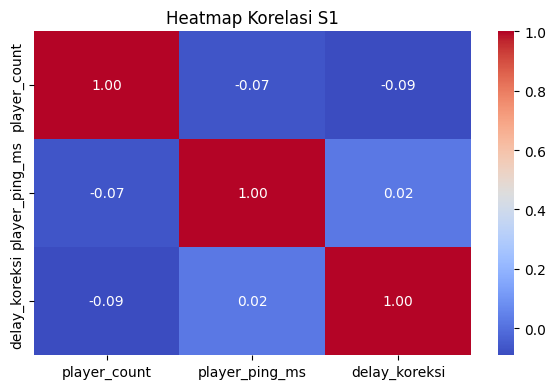

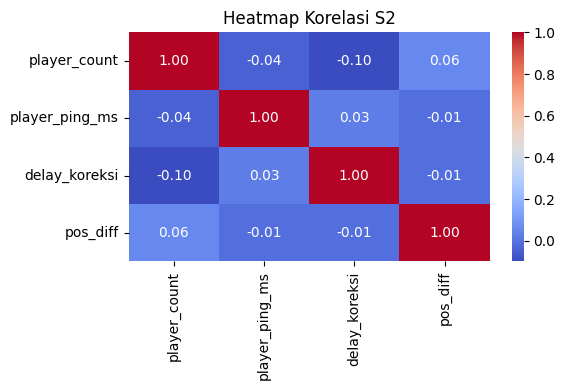

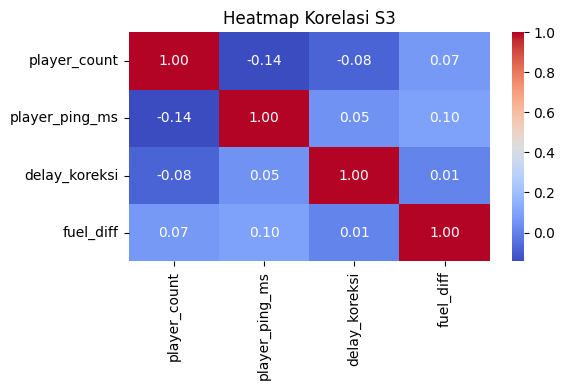

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for name, d, fitur in [("S1", df, fitur_s1), ("S2", df2, fitur_s2), ("S3", df3, fitur_s3)]:
    plt.figure(figsize=(6,4))
    sns.heatmap(d[fitur].corr(), annot=True, fmt=".2f", cmap="coolwarm")
    plt.title(f"Heatmap Korelasi {name}")
    plt.tight_layout()
    plt.show()

In [ ]:
# visible = 1, not_replicated = 0, invisible = 0
df["status_encoded"] = df["client_object_status"].map({
    "visible": 1,
    "not_replicated": 0,
    "invisible": 0
})

In [ ]:
df["client_object_status"].value_counts()

,count
client_object_status,
visible,4456


- S1 — semua status visible (100%), tidak ada variasi untuk clustering. Opsi: clustering 1 fitur atau analisis deskriptif saja
- S2 — fitur delay_koreksi + pos_diff, variasi data bagus
- S3 — fitur delay_koreksi + fuel_diff, variasi ada tapi mayoritas 0

In [ ]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================
import numpy as np

# --- S1: Status Objek ---
df["delay_koreksi"] = df["client_receive_time"] - df["server_event_time"] - 28800
df["status_encoded"] = df["client_object_status"].map({
    "visible": 1,
    "not_replicated": 0,
    "invisible": 0
})

# --- S2: Posisi Objek ---
df2["delay_koreksi"] = df2["client_receive_time"] - df2["server_event_time"] - 28800
df2["pos_diff"] = np.sqrt(
    (df2["server_pos_x"] - df2["client_pos_x"])**2 +
    (df2["server_pos_y"] - df2["client_pos_y"])**2 +
    (df2["server_pos_z"] - df2["client_pos_z"])**2
)

# --- S3: Status Global ---
df3["client_receive_time"]  = pd.to_numeric(df3["client_receive_time"], errors="coerce")
df3["server_event_time"]    = pd.to_numeric(df3["server_event_time"],   errors="coerce")
df3["server_fuel_value"]    = pd.to_numeric(df3["server_fuel_value"],   errors="coerce")
df3["client_fuel_value"]    = pd.to_numeric(df3["client_fuel_value"],   errors="coerce")

df3["delay_koreksi"] = df3["client_receive_time"] - df3["server_event_time"] - 28800
df3["fuel_diff"]     = (df3["server_fuel_value"] - df3["client_fuel_value"]).abs()

print("Feature engineering selesai.")
print(f"S1 shape: {df.shape}, S2 shape: {df2.shape}, S3 shape: {df3.shape}")

Feature engineering selesai.
S1 shape: (4456, 21), S2 shape: (7847, 21), S3 shape: (23663, 18)


In [ ]:
# ============================================================
# NORMALISASI DATA (MinMaxScaler)
# ============================================================
from sklearn.preprocessing import MinMaxScaler

# Fitur per skenario
fitur_s1 = ['player_count', 'player_ping_ms', 'delay_koreksi']
fitur_s2 = ['player_count', 'player_ping_ms', 'delay_koreksi', 'pos_diff']
fitur_s3 = ['player_count', 'player_ping_ms', 'delay_koreksi', 'fuel_diff']

# Drop baris yang masih ada NaN di fitur yang dipakai
df_s1  = df[fitur_s1].dropna().copy()
df_s2  = df2[fitur_s2].dropna().copy()
df_s3  = df3[fitur_s3].dropna().copy()

# Normalisasi
scaler = MinMaxScaler()
X_s1_scaled = scaler.fit_transform(df_s1)
X_s2_scaled = scaler.fit_transform(df_s2)
X_s3_scaled = scaler.fit_transform(df_s3)

print("Normalisasi selesai.")
print(f"S1 siap clustering: {X_s1_scaled.shape}")
print(f"S2 siap clustering: {X_s2_scaled.shape}")
print(f"S3 siap clustering: {X_s3_scaled.shape}")

Normalisasi selesai.
S1 siap clustering: (4456, 3)
S2 siap clustering: (7847, 4)
S3 siap clustering: (23663, 4)


#K-MEANS

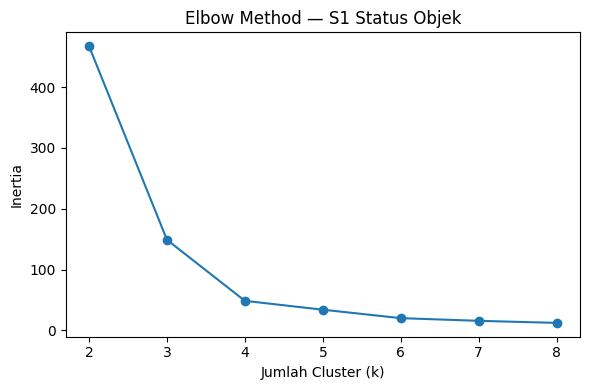

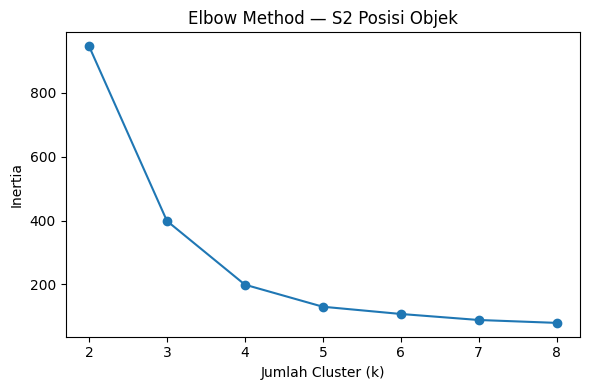

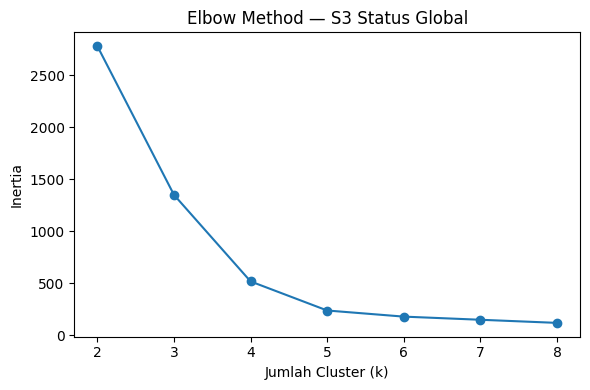

In [ ]:
# ============================================================
# ELBOW METHOD — CARI K OPTIMAL
# ============================================================
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def plot_elbow(X_scaled, label):
    inertias = []
    K_range = range(2, 9)
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X_scaled)
        inertias.append(km.inertia_)

    plt.figure(figsize=(6, 4))
    plt.plot(K_range, inertias, marker='o')
    plt.xlabel("Jumlah Cluster (k)")
    plt.ylabel("Inertia")
    plt.title(f"Elbow Method — {label}")
    plt.xticks(K_range)
    plt.tight_layout()
    plt.show()

plot_elbow(X_s1_scaled, "S1 Status Objek")
plot_elbow(X_s2_scaled, "S2 Posisi Objek")
plot_elbow(X_s3_scaled, "S3 Status Global")

### Mencoba Multiple K untuk Setiap Skenario

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans

def evaluate_kmeans_multiple_k(X_scaled, label, k_min=2, k_max=8):
    print(f"\n===== Evaluasi K-Means untuk {label} (k={k_min}-{k_max}) =====")
    results = []
    for k in range(k_min, k_max + 1):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)

        try:
            sil_score = silhouette_score(X_scaled, labels)
            db_index = davies_bouldin_score(X_scaled, labels)
            results.append({'k': k, 'Silhouette Score': sil_score, 'Davies-Bouldin Index': db_index})
            print(f"  k={k}: Silhouette Score = {sil_score:.4f}, Davies-Bouldin Index = {db_index:.4f}")
        except ValueError as e:
            print(f"  k={k}: Tidak dapat menghitung metrik. Error: {e}")
            results.append({'k': k, 'Silhouette Score': None, 'Davies-Bouldin Index': None})
    return pd.DataFrame(results)

# Evaluasi untuk S1
results_s1 = evaluate_kmeans_multiple_k(X_s1_scaled, "S1 Status Objek")
print("\nRingkasan Hasil S1:")
display(results_s1)

# Evaluasi untuk S2
results_s2 = evaluate_kmeans_multiple_k(X_s2_scaled, "S2 Posisi Objek")
print("\nRingkasan Hasil S2:")
display(results_s2)

# Evaluasi untuk S3
results_s3 = evaluate_kmeans_multiple_k(X_s3_scaled, "S3 Status Global")
print("\nRingkasan Hasil S3:")
display(results_s3)


===== Evaluasi K-Means untuk S1 Status Objek (k=2-8) =====
  k=2: Silhouette Score = 0.6996, Davies-Bouldin Index = 0.5870
  k=3: Silhouette Score = 0.8114, Davies-Bouldin Index = 0.3804
  k=4: Silhouette Score = 0.8577, Davies-Bouldin Index = 0.2043
  k=5: Silhouette Score = 0.7704, Davies-Bouldin Index = 0.2897
  k=6: Silhouette Score = 0.7904, Davies-Bouldin Index = 0.3008
  k=7: Silhouette Score = 0.8614, Davies-Bouldin Index = 0.2552
  k=8: Silhouette Score = 0.8501, Davies-Bouldin Index = 0.2548

Ringkasan Hasil S1:


,k,Silhouette Score,Davies-Bouldin Index
0,2,0.699567,0.587021
1,3,0.811435,0.380358
2,4,0.857678,0.204261
3,5,0.770376,0.289687
4,6,0.790413,0.300797
5,7,0.861405,0.255187
6,8,0.850074,0.254807



===== Evaluasi K-Means untuk S2 Posisi Objek (k=2-8) =====
  k=2: Silhouette Score = 0.6536, Davies-Bouldin Index = 0.6348
  k=3: Silhouette Score = 0.7160, Davies-Bouldin Index = 0.4532
  k=4: Silhouette Score = 0.7586, Davies-Bouldin Index = 0.3624
  k=5: Silhouette Score = 0.6928, Davies-Bouldin Index = 0.4381
  k=6: Silhouette Score = 0.6756, Davies-Bouldin Index = 0.5040
  k=7: Silhouette Score = 0.6756, Davies-Bouldin Index = 0.4778
  k=8: Silhouette Score = 0.6367, Davies-Bouldin Index = 0.6880

Ringkasan Hasil S2:


,k,Silhouette Score,Davies-Bouldin Index
0,2,0.653561,0.634788
1,3,0.715967,0.453173
2,4,0.758618,0.362359
3,5,0.692847,0.438122
4,6,0.675553,0.504008
5,7,0.675583,0.477841
6,8,0.636726,0.687972



===== Evaluasi K-Means untuk S3 Status Global (k=2-8) =====
  k=2: Silhouette Score = 0.6862, Davies-Bouldin Index = 0.5851
  k=3: Silhouette Score = 0.7687, Davies-Bouldin Index = 0.3808
  k=4: Silhouette Score = 0.8408, Davies-Bouldin Index = 0.2240
  k=5: Silhouette Score = 0.8636, Davies-Bouldin Index = 0.2961
  k=6: Silhouette Score = 0.8025, Davies-Bouldin Index = 0.3045
  k=7: Silhouette Score = 0.7682, Davies-Bouldin Index = 0.3723
  k=8: Silhouette Score = 0.7708, Davies-Bouldin Index = 0.3265

Ringkasan Hasil S3:


,k,Silhouette Score,Davies-Bouldin Index
0,2,0.686248,0.585145
1,3,0.768733,0.380758
2,4,0.840807,0.224032
3,5,0.863583,0.296064
4,6,0.802518,0.304469
5,7,0.768232,0.372346
6,8,0.770760,0.326466


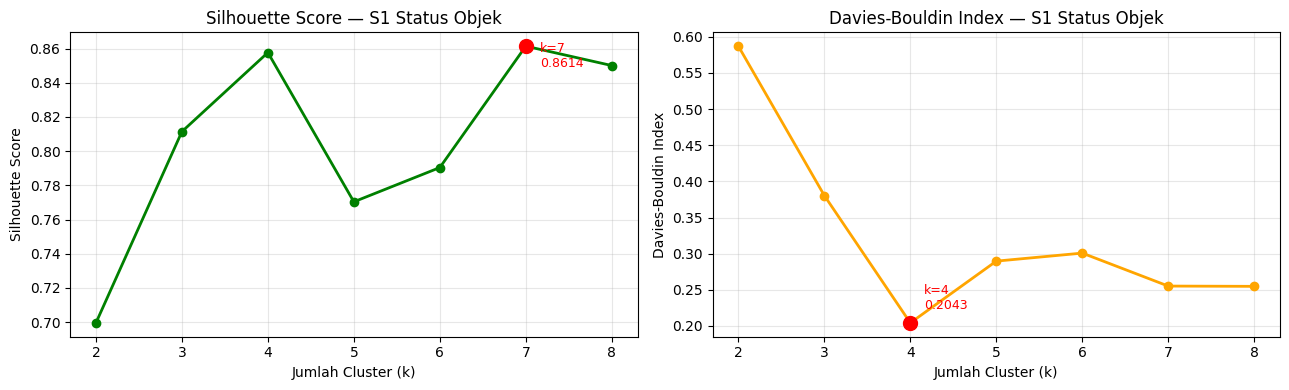

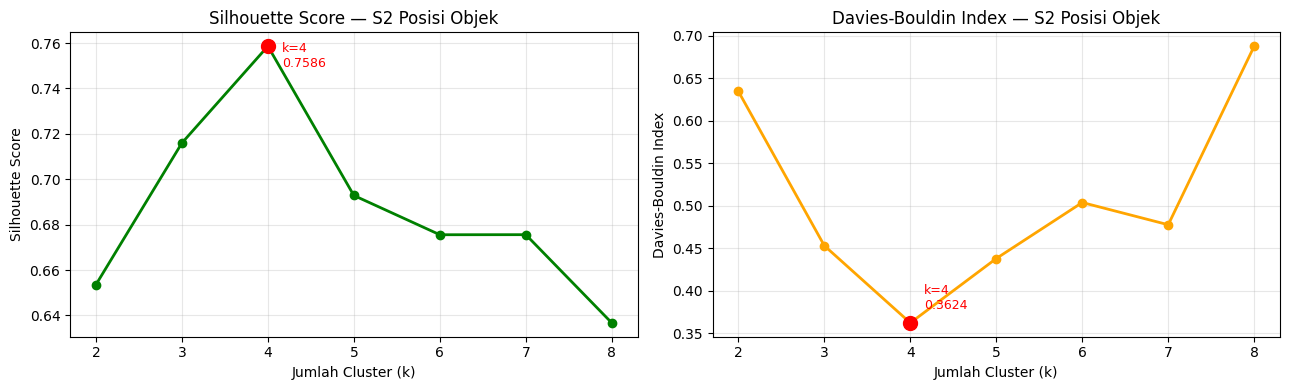

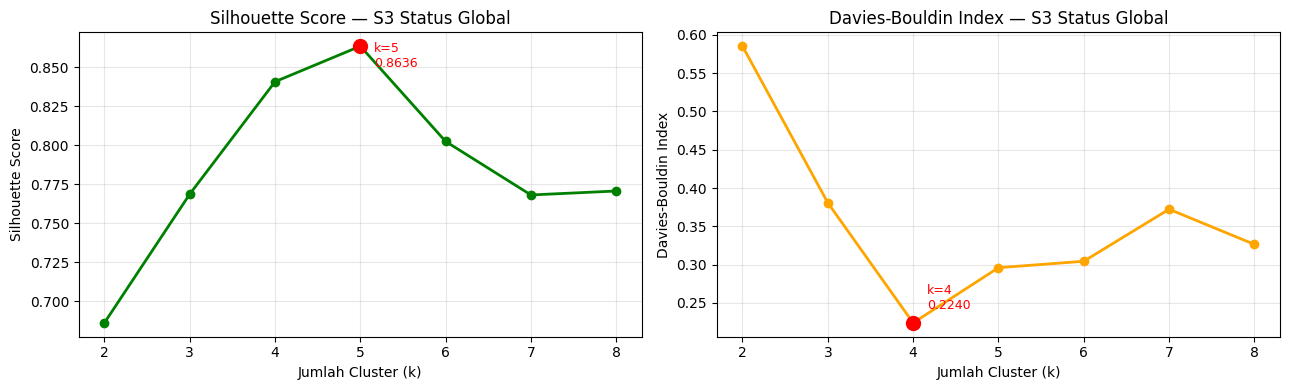

In [ ]:
# ============================================================
# VISUALISASI EVALUASI K-MEANS — S1, S2, S3
# Silhouette Score & Davies-Bouldin Index per k
# ============================================================
import matplotlib.pyplot as plt

def plot_evaluasi(results_df, label):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Plot Silhouette Score
    axes[0].plot(results_df["k"], results_df["Silhouette Score"],
                 marker='o', color='green', linewidth=2)
    axes[0].set_xlabel("Jumlah Cluster (k)")
    axes[0].set_ylabel("Silhouette Score")
    axes[0].set_title(f"Silhouette Score — {label}")
    axes[0].set_xticks(results_df["k"])
    axes[0].grid(alpha=0.3)

    # Tandai titik tertinggi
    idx_max = results_df["Silhouette Score"].idxmax()
    k_max = results_df.loc[idx_max, "k"]
    sil_max = results_df.loc[idx_max, "Silhouette Score"]
    axes[0].scatter([k_max], [sil_max], color='red', s=100, zorder=5)
    axes[0].annotate(f"k={k_max}\n{sil_max:.4f}",
                      (k_max, sil_max), textcoords="offset points",
                      xytext=(10, -15), fontsize=9, color='red')

    # Plot Davies-Bouldin Index
    axes[1].plot(results_df["k"], results_df["Davies-Bouldin Index"],
                 marker='o', color='orange', linewidth=2)
    axes[1].set_xlabel("Jumlah Cluster (k)")
    axes[1].set_ylabel("Davies-Bouldin Index")
    axes[1].set_title(f"Davies-Bouldin Index — {label}")
    axes[1].set_xticks(results_df["k"])
    axes[1].grid(alpha=0.3)

    # Tandai titik terendah (DBI: makin kecil makin baik)
    idx_min = results_df["Davies-Bouldin Index"].idxmin()
    k_min = results_df.loc[idx_min, "k"]
    db_min = results_df.loc[idx_min, "Davies-Bouldin Index"]
    axes[1].scatter([k_min], [db_min], color='red', s=100, zorder=5)
    axes[1].annotate(f"k={k_min}\n{db_min:.4f}",
                      (k_min, db_min), textcoords="offset points",
                      xytext=(10, 10), fontsize=9, color='red')

    plt.tight_layout()
    plt.show()

# Plot untuk ketiga skenario
plot_evaluasi(results_s1, "S1 Status Objek")
plot_evaluasi(results_s2, "S2 Posisi Objek")
plot_evaluasi(results_s3, "S3 Status Global")

In [ ]:
# ============================================================
# CLUSTERING S1 — Bandingkan k=4 vs k=7 (tanpa spawn_delay)
# ============================================================

# k=4
km_s1_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_k4 = km_s1_k4.fit_predict(X_s1_scaled)

temp_k4 = df_s1[fitur_s1].copy()
temp_k4["cluster"] = labels_k4
print("===== Centroid S1 k=4 (tanpa spawn_delay) =====")
display(temp_k4.groupby("cluster")[fitur_s1].mean())
print("\nJumlah data per cluster:")
print(temp_k4["cluster"].value_counts().sort_index())

print("\n" + "="*60 + "\n")

# k=7
km_s1_k7 = KMeans(n_clusters=7, random_state=42, n_init=10)
labels_k7 = km_s1_k7.fit_predict(X_s1_scaled)

temp_k7 = df_s1[fitur_s1].copy()
temp_k7["cluster"] = labels_k7
print("===== Centroid S1 k=7 (tanpa spawn_delay) =====")
display(temp_k7.groupby("cluster")[fitur_s1].mean())
print("\nJumlah data per cluster:")
print(temp_k7["cluster"].value_counts().sort_index())

===== Centroid S1 k=4 (tanpa spawn_delay) =====


,player_count,player_ping_ms,delay_koreksi
cluster,,,
0,4.0,82.049107,-0.764881
1,2.0,89.232877,-0.712329
2,4.0,82.049107,4.741071
3,2.0,100.638889,5.055556



Jumlah data per cluster:
cluster
0    2688
1     584
2     896
3     288
Name: count, dtype: int64


===== Centroid S1 k=7 (tanpa spawn_delay) =====


,player_count,player_ping_ms,delay_koreksi
cluster,,,
0,4.0,76.722388,-1.000000
1,2.0,89.232877,-0.712329
2,4.0,78.035874,4.744395
3,2.0,100.638889,5.055556
4,4.0,76.213483,-2.000000
5,4.0,977.000000,0.000000
6,4.0,80.493878,0.012245



Jumlah data per cluster:
cluster
0    1340
1     584
2     892
3     288
4     356
5      16
6     980
Name: count, dtype: int64


In [ ]:
# ============================================================
# CLUSTERING S2 — k=4
# ============================================================

km_s2_final = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_s2 = km_s2_final.fit_predict(X_s2_scaled)

temp_s2 = df_s2[fitur_s2].copy()
temp_s2["cluster"] = labels_s2
print("===== Centroid S2 k=4 =====")
display(temp_s2.groupby("cluster")[fitur_s2].mean())
print("\nJumlah data per cluster:")
print(temp_s2["cluster"].value_counts().sort_index())

===== Centroid S2 k=4 =====


,player_count,player_ping_ms,delay_koreksi,pos_diff
cluster,,,,
0,4.0,81.051383,-0.824989,3874.002020
1,2.0,94.894215,4.890909,3456.898631
2,4.0,81.051383,4.719368,3703.677159
3,2.0,84.155556,-0.762393,2601.647244



Jumlah data per cluster:
cluster
0    4554
1     605
2    1518
3    1170
Name: count, dtype: int64


In [ ]:
# ============================================================
# CLUSTERING S3 — k=5
# ============================================================

km_s3_final = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_s3 = km_s3_final.fit_predict(X_s3_scaled)

temp_s3 = df_s3[fitur_s3].copy()
temp_s3["cluster"] = labels_s3
print("===== Centroid S3 k=5 =====")
display(temp_s3.groupby("cluster")[fitur_s3].mean())
print("\nJumlah data per cluster:")
print(temp_s3["cluster"].value_counts().sort_index())

===== Centroid S3 k=5 =====


,player_count,player_ping_ms,delay_koreksi,fuel_diff
cluster,,,,
0,4.0,77.483673,4.660714,6.298214
1,4.0,77.474428,-0.861033,4.830312
2,2.0,86.320900,-0.785192,10.989316
3,2.0,94.616480,4.955997,27.704055
4,4.0,77.294985,0.601770,3474.764012



Jumlah data per cluster:
cluster
0     3920
1    11751
2     5335
3     2318
4      339
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans

def validasi_clustering(X_scaled, labels, label):
    sil_score = silhouette_score(X_scaled, labels)
    db_index = davies_bouldin_score(X_scaled, labels)
    print(f"\n[{label}]")
    print(f"  Silhouette Score      : {sil_score:.4f}  (makin tinggi makin baik, ideal > 0.5)")
    print(f"  Davies-Bouldin Index  : {db_index:.4f}  (makin kecil makin baik, ideal < 1.0)")
    return sil_score, db_index

# Cek dan bersihkan outlier ping ekstrem
print(df_s1[df_s1["player_ping_ms"] > 300])
df_s1_clean = df_s1[df_s1["player_ping_ms"] <= 300].copy()
print(f"Baris dibuang: {len(df_s1) - len(df_s1_clean)}")
print(f"Sisa data: {len(df_s1_clean)}")

# Normalisasi ulang dengan data bersih
X_s1_scaled_clean = scaler.fit_transform(df_s1_clean[fitur_s1])

# Validasi ulang k=4 dengan data bersih
km_s1_final = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_s1_final = km_s1_final.fit_predict(X_s1_scaled_clean)
sil_s1_final, db_s1_final = validasi_clustering(X_s1_scaled_clean, labels_s1_final, "S1 (k=4, bersih)")

      player_count  player_ping_ms  delay_koreksi
384              4             977             -2
385              4             977             -2
386              4             977             -2
387              4             977             -2
388              4             977             -1
389              4             977             -1
390              4             977             -1
391              4             977             -1
392              4             977             -1
393              4             977             -1
394              4             977             -1
395              4             977             -1
396              4             977              4
397              4             977              4
398              4             977              4
399              4             977              4
3728             2             342             -1
3729             2             342             -1
3730             2             342             -1


In [ ]:
# ============================================================
# CENTROID FINAL S1 (k=4, data bersih)
# ============================================================

temp_s1_final = df_s1_clean[fitur_s1].copy()
temp_s1_final["cluster"] = labels_s1_final

print("===== Centroid S1 k=4 (FINAL, data bersih) =====")
display(temp_s1_final.groupby("cluster")[fitur_s1].mean())
print("\nJumlah data per cluster:")
print(temp_s1_final["cluster"].value_counts().sort_index())

===== Centroid S1 k=4 (FINAL, data bersih) =====


,player_count,player_ping_ms,delay_koreksi
cluster,,,
0,4.0,78.035874,-0.762332
1,2.0,82.699301,-0.713287
2,4.0,78.035874,4.744395
3,2.0,87.594203,5.057971



Jumlah data per cluster:
cluster
0    2676
1     572
2     892
3     276
Name: count, dtype: int64


##label scenario 1

In [ ]:
label_map_s1 = {
    0: "Sinkron",       # 4P, delay negatif
    1: "Sinkron",       # 2P, delay negatif
    2: "Tidak Sinkron", # 4P, delay positif
    3: "Tidak Sinkron"  # 2P, delay positif
}

temp_s1_final["kondisi"] = temp_s1_final["cluster"].map(label_map_s1)
print(temp_s1_final["kondisi"].value_counts())

kondisi
Sinkron          3248
Tidak Sinkron    1168
Name: count, dtype: int64


In [ ]:
print("===== S1 — Distribusi Kondisi per Player Count (FINAL) =====")
tabel_s1 = temp_s1_final.groupby(["player_count", "kondisi"]).size().unstack(fill_value=0)
display(tabel_s1)

tabel_s1_pct = tabel_s1.div(tabel_s1.sum(axis=1), axis=0) * 100
print("\nDalam persen (%):")
display(tabel_s1_pct.round(1))

===== S1 — Distribusi Kondisi per Player Count (FINAL) =====


kondisi,Sinkron,Tidak Sinkron
player_count,,
2,572,276
4,2676,892



Dalam persen (%):


kondisi,Sinkron,Tidak Sinkron
player_count,,
2,67.5,32.5
4,75.0,25.0


##Label Scenario 2

In [ ]:
label_map_s2 = {
    3: "Baik",    # 2P, pos_diff terendah (2601)
    1: "Sedang",  # 2P, pos_diff menengah (3456)
    2: "Buruk",   # 4P, pos_diff tinggi (3703)
    0: "Buruk"    # 4P, pos_diff tertinggi (3874)
}

temp_s2["kondisi"] = temp_s2["cluster"].map(label_map_s2)
print(temp_s2["kondisi"].value_counts())

kondisi
Buruk     6072
Baik      1170
Sedang     605
Name: count, dtype: int64


In [ ]:
print("===== S2 — Distribusi Kondisi per Player Count (FINAL) =====")
tabel_s2 = temp_s2.groupby(["player_count", "kondisi"]).size().unstack(fill_value=0)
display(tabel_s2)

tabel_s2_pct = tabel_s2.div(tabel_s2.sum(axis=1), axis=0) * 100
print("\nDalam persen (%):")
display(tabel_s2_pct.round(1))

===== S2 — Distribusi Kondisi per Player Count (FINAL) =====


kondisi,Baik,Buruk,Sedang
player_count,,,
2,1170,0,605
4,0,6072,0



Dalam persen (%):


kondisi,Baik,Buruk,Sedang
player_count,,,
2,65.9,0.0,34.1
4,0.0,100.0,0.0


##Label Scenario 3

In [ ]:
label_map_s3 = {
    1: "Sangat Baik",  # 4P, fuel_diff 4.83
    2: "Baik",         # 2P, fuel_diff 10.99
    0: "Sedang",       # 4P, fuel_diff 6.30
    3: "Buruk",        # 2P, fuel_diff 27.70
    4: "Kritis"         # 4P, fuel_diff 3474 (ekstrem)
}

temp_s3["kondisi"] = temp_s3["cluster"].map(label_map_s3)
print(temp_s3["kondisi"].value_counts())

kondisi
Sangat Baik    11751
Baik            5335
Sedang          3920
Buruk           2318
Kritis           339
Name: count, dtype: int64


In [ ]:
print("===== S3 — Distribusi Kondisi per Player Count (FINAL) =====")
tabel_s3 = temp_s3.groupby(["player_count", "kondisi"]).size().unstack(fill_value=0)
display(tabel_s3)

tabel_s3_pct = tabel_s3.div(tabel_s3.sum(axis=1), axis=0) * 100
print("\nDalam persen (%):")
display(tabel_s3_pct.round(1))

===== S3 — Distribusi Kondisi per Player Count (FINAL) =====


kondisi,Baik,Buruk,Kritis,Sangat Baik,Sedang
player_count,,,,,
2,5335,2318,0,0,0
4,0,0,339,11751,3920



Dalam persen (%):


kondisi,Baik,Buruk,Kritis,Sangat Baik,Sedang
player_count,,,,,
2,69.7,30.3,0.0,0.0,0.0
4,0.0,0.0,2.1,73.4,24.5


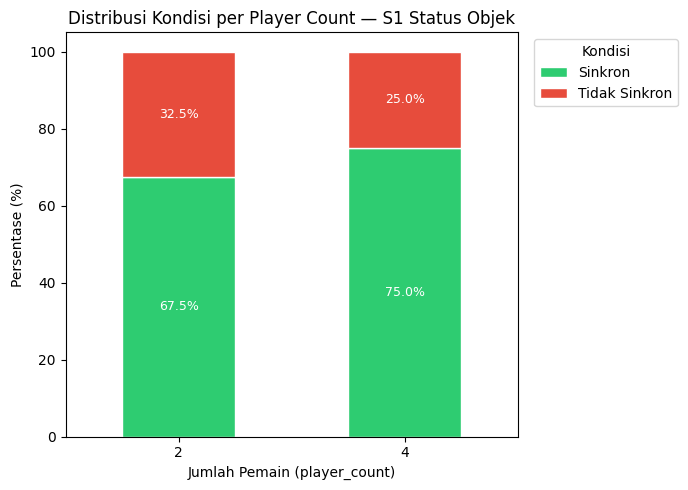

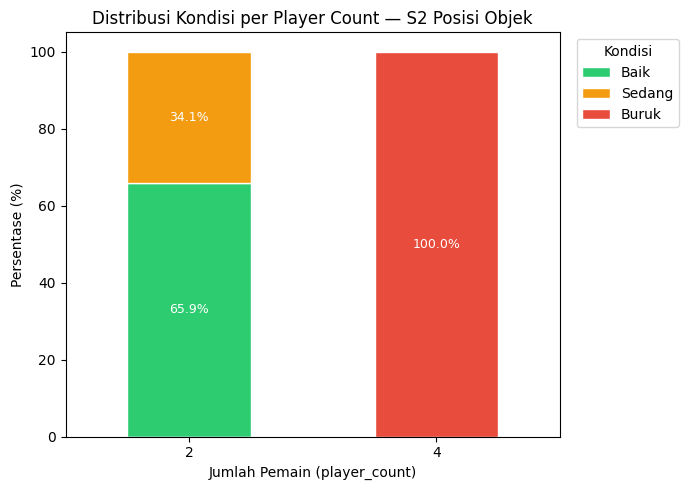

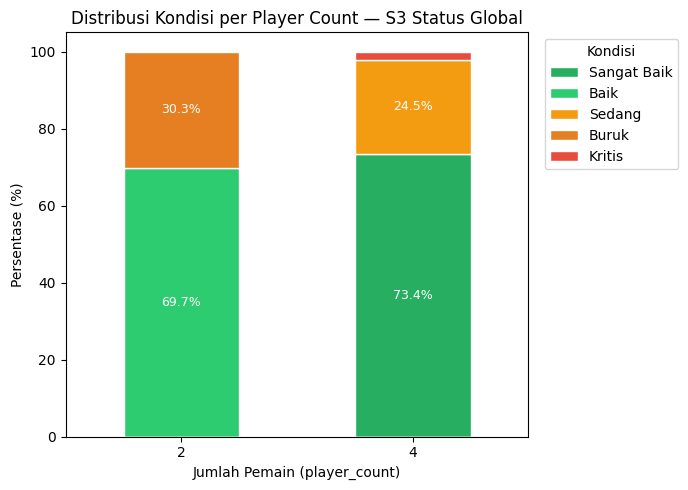

In [ ]:
import matplotlib.pyplot as plt

def plot_distribusi_kondisi(tabel_pct, label, urutan_kondisi, warna):
    tabel_plot = tabel_pct[urutan_kondisi]  # urutkan kolom sesuai severity

    ax = tabel_plot.plot(kind="bar", stacked=True, figsize=(7, 5),
                          color=warna, edgecolor="white")
    plt.title(f"Distribusi Kondisi per Player Count — {label}")
    plt.xlabel("Jumlah Pemain (player_count)")
    plt.ylabel("Persentase (%)")
    plt.xticks(rotation=0)
    plt.legend(title="Kondisi", bbox_to_anchor=(1.02, 1), loc="upper left")

    # Tambahkan label angka di tiap segmen bar
    for c in ax.containers:
        labels_text = [f"{v:.1f}%" if v > 3 else "" for v in c.datavalues]
        ax.bar_label(c, labels=labels_text, label_type="center", fontsize=9, color="white")

    plt.tight_layout()
    plt.show()

# S1 — 2 kondisi
plot_distribusi_kondisi(
    tabel_s1_pct, "S1 Status Objek",
    urutan_kondisi=["Sinkron", "Tidak Sinkron"],
    warna=["#2ecc71", "#e74c3c"]
)

# S2 — 3 kondisi
plot_distribusi_kondisi(
    tabel_s2_pct, "S2 Posisi Objek",
    urutan_kondisi=["Baik", "Sedang", "Buruk"],
    warna=["#2ecc71", "#f39c12", "#e74c3c"]
)

# S3 — 5 kondisi
plot_distribusi_kondisi(
    tabel_s3_pct, "S3 Status Global",
    urutan_kondisi=["Sangat Baik", "Baik", "Sedang", "Buruk", "Kritis"],
    warna=["#27ae60", "#2ecc71", "#f39c12", "#e67e22", "#e74c3c"]
)

In [ ]:
# 1. Validasi final S2 dan S3 (WAJIB sebelum lanjut ke skripsi)
sil_s2, db_s2 = validasi_clustering(X_s2_scaled, labels_s2, "S2 (k=4, FINAL)")
sil_s3, db_s3 = validasi_clustering(X_s3_scaled, labels_s3, "S3 (k=5, FINAL)")


[S2 (k=4, FINAL)]
  Silhouette Score      : 0.7586  (makin tinggi makin baik, ideal > 0.5)
  Davies-Bouldin Index  : 0.3624  (makin kecil makin baik, ideal < 1.0)

[S3 (k=5, FINAL)]
  Silhouette Score      : 0.8636  (makin tinggi makin baik, ideal > 0.5)
  Davies-Bouldin Index  : 0.2961  (makin kecil makin baik, ideal < 1.0)


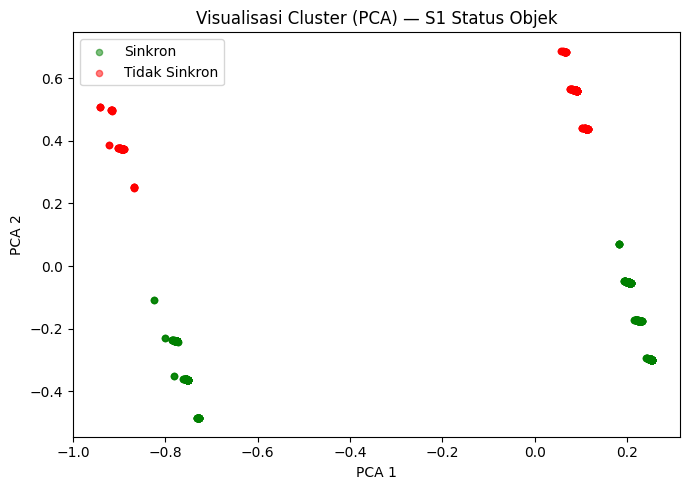

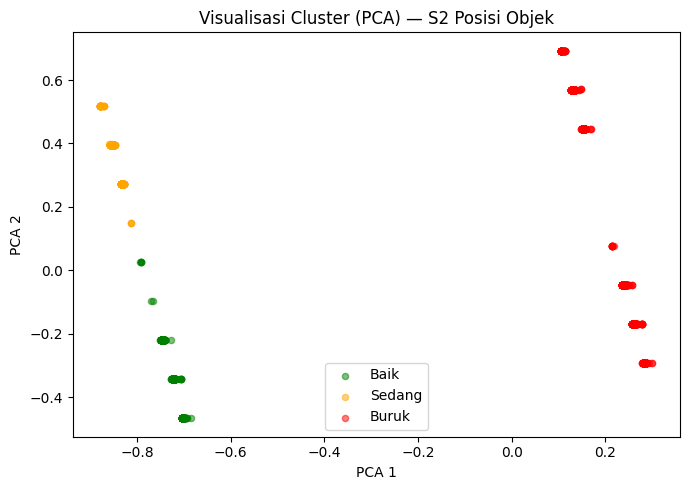

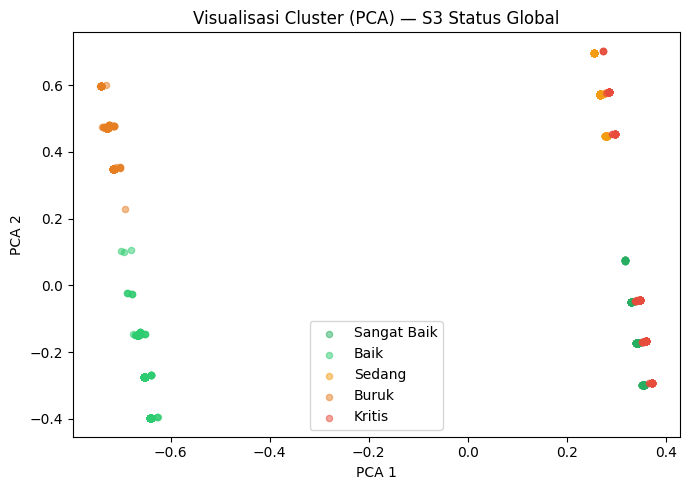

In [ ]:
# 2. Visualisasi PCA untuk ketiga skenario
from sklearn.decomposition import PCA

def plot_cluster_pca(X_scaled, kondisi_labels, label, palette):
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(7, 5))
    for kondisi, color in palette.items():
        mask = kondisi_labels == kondisi
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=kondisi, alpha=0.5, s=20)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"Visualisasi Cluster (PCA) — {label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# S1 — pakai X_s1_scaled_clean (data yang sudah bersih dari outlier)
plot_cluster_pca(X_s1_scaled_clean, temp_s1_final["kondisi"].values, "S1 Status Objek",
                  {"Sinkron": "green", "Tidak Sinkron": "red"})

plot_cluster_pca(X_s2_scaled, temp_s2["kondisi"].values, "S2 Posisi Objek",
                  {"Baik": "green", "Sedang": "orange", "Buruk": "red"})

plot_cluster_pca(X_s3_scaled, temp_s3["kondisi"].values, "S3 Status Global",
                  {"Sangat Baik": "#27ae60", "Baik": "#2ecc71", "Sedang": "#f39c12",
                   "Buruk": "#e67e22", "Kritis": "#e74c3c"})

#DBSCAN

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Helper validasi (sama seperti yang sudah kamu pakai)
def validasi_clustering(X_scaled, labels, label_nama):
    # Filter noise DBSCAN (label = -1)
    mask = labels != -1
    n_cluster = len(set(labels[mask]))
    n_noise = np.sum(labels == -1)

    if n_cluster < 2:
        print(f"[{label_nama}] Hanya {n_cluster} cluster — tidak bisa hitung metrik.")
        return None, None

    sil = silhouette_score(X_scaled[mask], labels[mask])
    db  = davies_bouldin_score(X_scaled[mask], labels[mask])
    print(f"[{label_nama}] Clusters: {n_cluster} | Noise: {n_noise} | Silhouette: {sil:.4f} | Davies-Bouldin: {db:.4f}")
    return sil, db

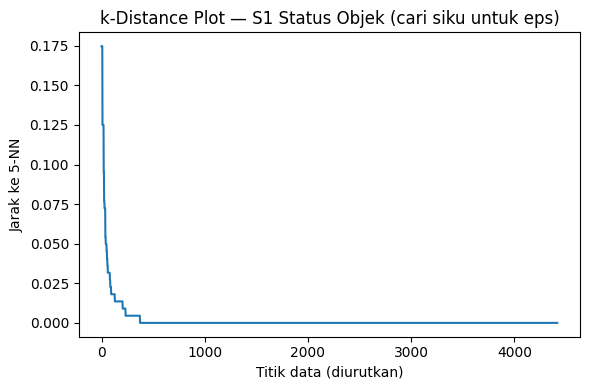

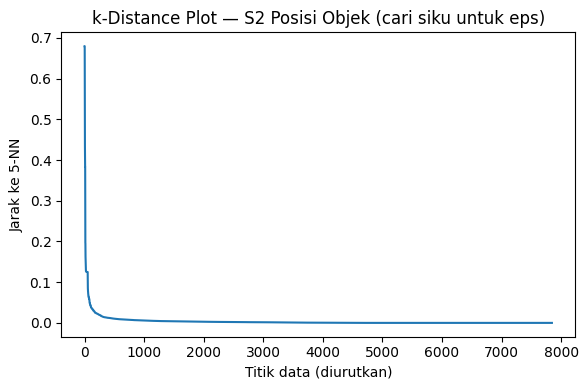

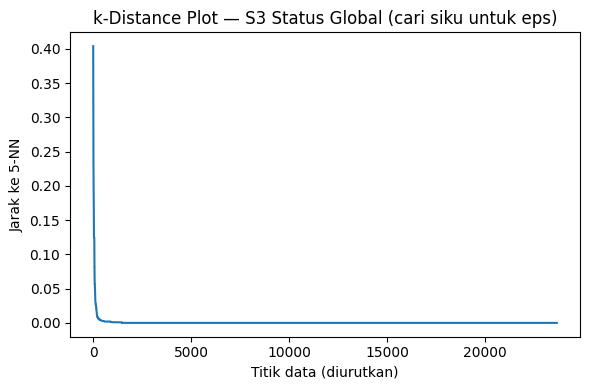

In [ ]:
from sklearn.neighbors import NearestNeighbors

def plot_kdistance(X_scaled, k=5, label=""):
    nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
    distances, _ = nbrs.kneighbors(X_scaled)
    k_dist = np.sort(distances[:, k-1])[::-1]

    plt.figure(figsize=(6, 4))
    plt.plot(k_dist)
    plt.xlabel("Titik data (diurutkan)")
    plt.ylabel(f"Jarak ke {k}-NN")
    plt.title(f"k-Distance Plot — {label} (cari siku untuk eps)")
    plt.tight_layout()
    plt.show()

plot_kdistance(X_s1_scaled_clean, label="S1 Status Objek")
plot_kdistance(X_s2_scaled,       label="S2 Posisi Objek")
plot_kdistance(X_s3_scaled,       label="S3 Status Global")

In [ ]:
# ============================================================
# DBSCAN — S1 Status Objek
# ============================================================
# Tuning: ubah eps setelah lihat k-distance plot
db_s1 = DBSCAN(eps=0.15, min_samples=6)   # <-- sesuaikan eps
labels_db_s1 = db_s1.fit_predict(X_s1_scaled_clean)

print("Cluster unik S1:", np.unique(labels_db_s1))
print("Jumlah per cluster (termasuk noise=-1):")
print(pd.Series(labels_db_s1).value_counts().sort_index())

validasi_clustering(X_s1_scaled_clean, labels_db_s1, "DBSCAN S1")

Cluster unik S1: [-1  0  1  2  3  4  5]
Jumlah per cluster (termasuk noise=-1):
-1       8
 0     892
 1    2676
 2     560
 3     264
 4       8
 5       8
Name: count, dtype: int64
[DBSCAN S1] Clusters: 6 | Noise: 8 | Silhouette: 0.8130 | Davies-Bouldin: 0.2180


(np.float64(0.8129513995595434), np.float64(0.2179935473362248))

In [ ]:
# ============================================================
# DBSCAN — S2 Posisi Objek
# ============================================================
db_s2 = DBSCAN(eps=0.15, min_samples=8)   # <-- sesuaikan eps
labels_db_s2 = db_s2.fit_predict(X_s2_scaled)

print("Cluster unik S2:", np.unique(labels_db_s2))
print(pd.Series(labels_db_s2).value_counts().sort_index())

validasi_clustering(X_s2_scaled, labels_db_s2, "DBSCAN S2")

Cluster unik S2: [-1  0  1  2  3  4]
-1      29
 0    4525
 1    1506
 2      11
 3      15
 4    1761
Name: count, dtype: int64
[DBSCAN S2] Clusters: 5 | Noise: 29 | Silhouette: 0.6701 | Davies-Bouldin: 0.4013


(np.float64(0.670097079640351), np.float64(0.4012919923672483))

In [ ]:
# ============================================================
# DBSCAN — S3 Status Global
# ============================================================
db_s3 = DBSCAN(eps=0.15, min_samples=8)   # <-- sesuaikan eps
labels_db_s3 = db_s3.fit_predict(X_s3_scaled)

print("Cluster unik S3:", np.unique(labels_db_s3))
print(pd.Series(labels_db_s3).value_counts().sort_index())

validasi_clustering(X_s3_scaled, labels_db_s3, "DBSCAN S3")

Cluster unik S3: [-1  0  1  2  3  4  5  6  7  8  9 10 11]
-1        31
 0     11706
 1      3902
 2        21
 3       237
 4        81
 5        14
 6        42
 7      5306
 8      2291
 9        10
 10       14
 11        8
Name: count, dtype: int64
[DBSCAN S3] Clusters: 12 | Noise: 31 | Silhouette: 0.7148 | Davies-Bouldin: 0.3224


(np.float64(0.7147930974734391), np.float64(0.32235631416743515))

/tmp/ipykernel_976/3103133522.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', max(unique_labels) + 1)


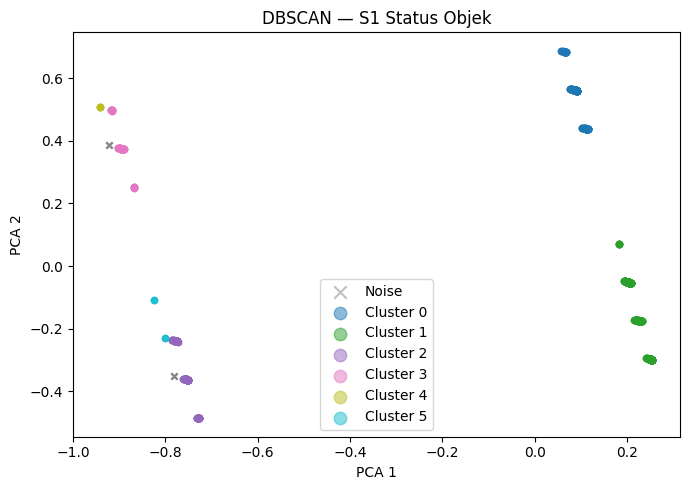

/tmp/ipykernel_976/3103133522.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', max(unique_labels) + 1)


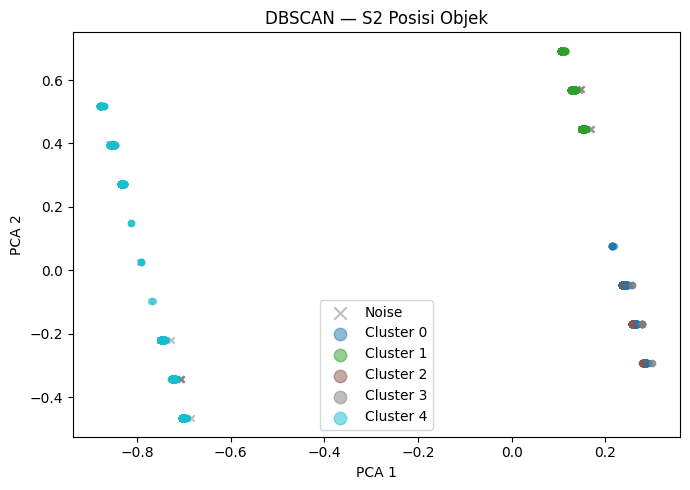

/tmp/ipykernel_976/3103133522.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', max(unique_labels) + 1)


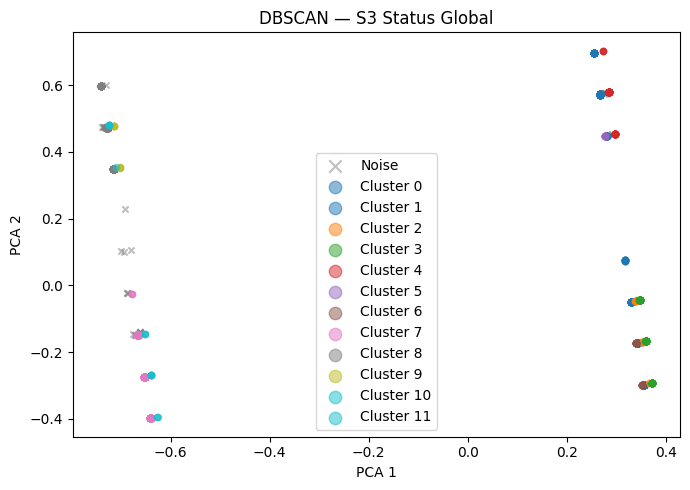

In [ ]:
def plot_pca_dbscan(X_scaled, labels, label_nama):
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    unique_labels = sorted(set(labels))
    cmap = plt.cm.get_cmap('tab10', max(unique_labels) + 1)

    plt.figure(figsize=(7, 5))
    for lbl in unique_labels:
        mask = labels == lbl
        color = 'grey' if lbl == -1 else cmap(lbl)
        nama  = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color],
                    label=nama, alpha=0.5, s=20,
                    marker='x' if lbl == -1 else 'o')

    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"DBSCAN — {label_nama}")
    plt.legend(markerscale=2)
    plt.tight_layout()
    plt.show()

plot_pca_dbscan(X_s1_scaled_clean, labels_db_s1, "S1 Status Objek")
plot_pca_dbscan(X_s2_scaled,       labels_db_s2, "S2 Posisi Objek")
plot_pca_dbscan(X_s3_scaled,       labels_db_s3, "S3 Status Global")

#Agglomerative

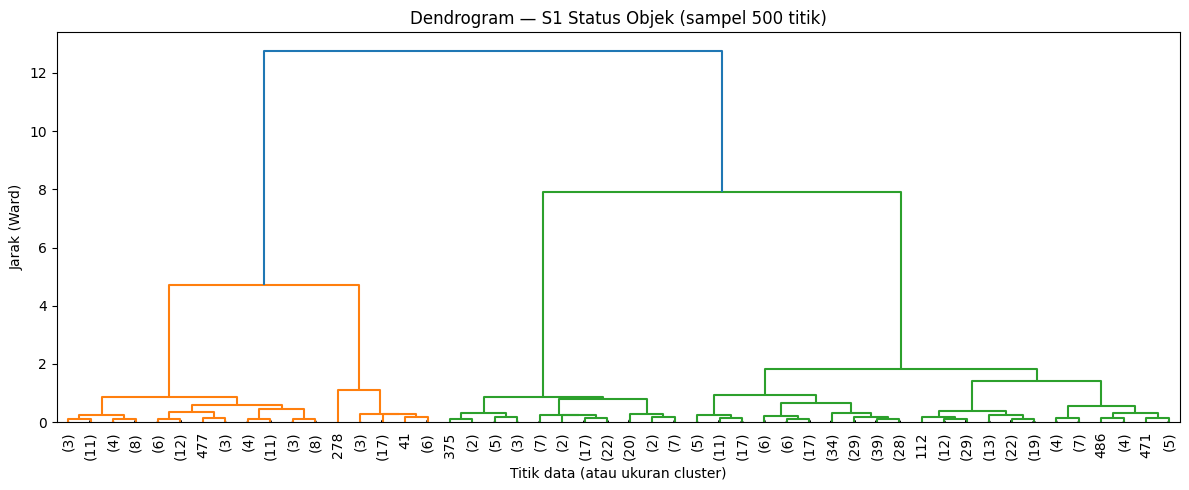

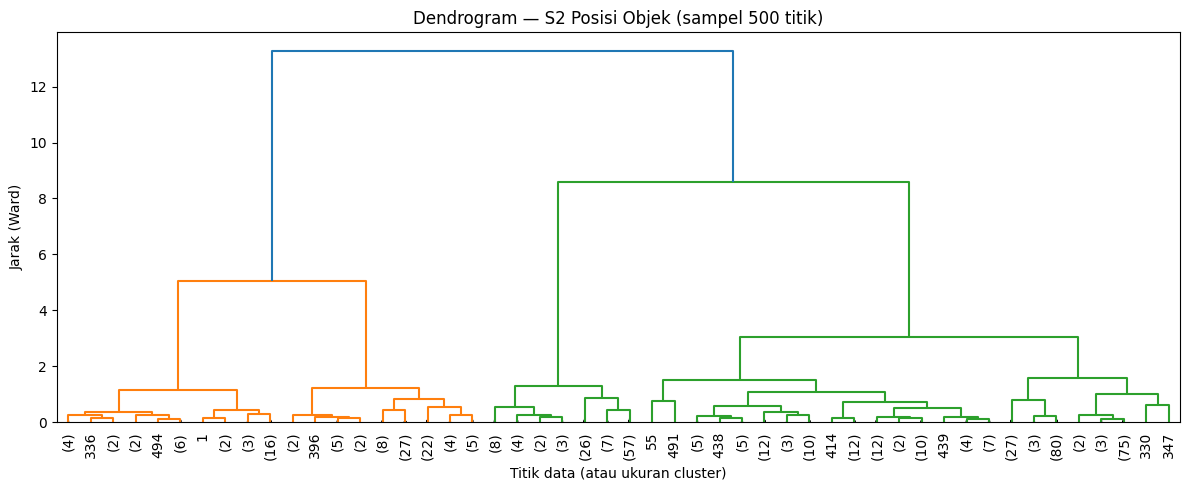

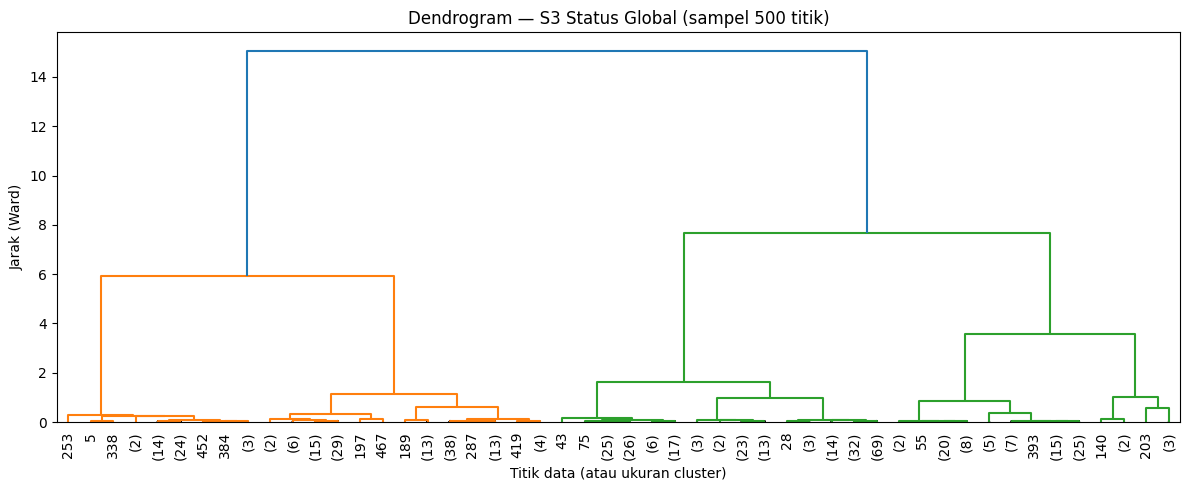

In [ ]:
def plot_dendrogram(X_scaled, label_nama, method='ward', max_display=50):
    # Sampling jika data terlalu besar (dendrogram jadi lambat di > 500 titik)
    if len(X_scaled) > 500:
        idx = np.random.choice(len(X_scaled), 500, replace=False)
        X_sample = X_scaled[idx]
        catatan = " (sampel 500 titik)"
    else:
        X_sample = X_scaled
        catatan = ""

    Z = linkage(X_sample, method=method)

    plt.figure(figsize=(12, 5))
    dendrogram(Z, truncate_mode='lastp', p=max_display,
               leaf_rotation=90, leaf_font_size=10,
               show_contracted=True)
    plt.title(f"Dendrogram — {label_nama}{catatan}")
    plt.xlabel("Titik data (atau ukuran cluster)")
    plt.ylabel("Jarak (Ward)")
    plt.tight_layout()
    plt.show()

plot_dendrogram(X_s1_scaled_clean, "S1 Status Objek")
plot_dendrogram(X_s2_scaled,       "S2 Posisi Objek")
plot_dendrogram(X_s3_scaled,       "S3 Status Global")

In [ ]:
def evaluate_agglomerative(X_scaled, label, k_min=2, k_max=8):
    print(f"\n===== Evaluasi Agglomerative untuk {label} (k={k_min}-{k_max}) =====")
    results = []
    for k in range(k_min, k_max + 1):
        agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
        lbls = agg.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, lbls)
        db  = davies_bouldin_score(X_scaled, lbls)
        results.append({'k': k, 'Silhouette Score': sil, 'Davies-Bouldin Index': db})
        print(f"  k={k}: Silhouette = {sil:.4f} | Davies-Bouldin = {db:.4f}")
    return pd.DataFrame(results)

res_agg_s1 = evaluate_agglomerative(X_s1_scaled_clean, "S1 Status Objek")
res_agg_s2 = evaluate_agglomerative(X_s2_scaled,       "S2 Posisi Objek")
res_agg_s3 = evaluate_agglomerative(X_s3_scaled,       "S3 Status Global")


===== Evaluasi Agglomerative untuk S1 Status Objek (k=2-8) =====
  k=2: Silhouette = 0.6799 | Davies-Bouldin = 0.6137
  k=3: Silhouette = 0.7686 | Davies-Bouldin = 0.4161
  k=4: Silhouette = 0.8055 | Davies-Bouldin = 0.3265
  k=5: Silhouette = 0.8125 | Davies-Bouldin = 0.4346
  k=6: Silhouette = 0.6301 | Davies-Bouldin = 0.6308
  k=7: Silhouette = 0.6676 | Davies-Bouldin = 0.5654
  k=8: Silhouette = 0.7087 | Davies-Bouldin = 0.5381

===== Evaluasi Agglomerative untuk S2 Posisi Objek (k=2-8) =====
  k=2: Silhouette = 0.6536 | Davies-Bouldin = 0.6348
  k=3: Silhouette = 0.7148 | Davies-Bouldin = 0.4530
  k=4: Silhouette = 0.7572 | Davies-Bouldin = 0.3637
  k=5: Silhouette = 0.6661 | Davies-Bouldin = 0.4964
  k=6: Silhouette = 0.6404 | Davies-Bouldin = 0.5798
  k=7: Silhouette = 0.6555 | Davies-Bouldin = 0.5349
  k=8: Silhouette = 0.6631 | Davies-Bouldin = 0.5337

===== Evaluasi Agglomerative untuk S3 Status Global (k=2-8) =====
  k=2: Silhouette = 0.6862 | Davies-Bouldin = 0.5851
  k=3:

In [ ]:
# ============================================================
# Agglomerative — S1 (gunakan k yang sama dengan K-Means untuk perbandingan adil)
# ============================================================
agg_s1 = AgglomerativeClustering(n_clusters=4, linkage='ward')  # <-- sesuaikan k
labels_agg_s1 = agg_s1.fit_predict(X_s1_scaled_clean)

temp_agg_s1 = df_s1_clean[fitur_s1].copy()
temp_agg_s1['cluster'] = labels_agg_s1
print("===== Centroid Agglomerative S1 (k=4) =====")
display(temp_agg_s1.groupby('cluster')[fitur_s1].mean())
print("Jumlah per cluster:", temp_agg_s1['cluster'].value_counts().sort_index().to_dict())

validasi_clustering(X_s1_scaled_clean, labels_agg_s1, "Agglomerative S1 k=4")

===== Centroid Agglomerative S1 (k=4) =====


,player_count,player_ping_ms,delay_koreksi
cluster,,,
0,2.0,94.736111,4.847222
1,4.0,78.035874,-0.762332
2,4.0,78.035874,4.744395
3,2.0,78.921429,-0.728571


Jumlah per cluster: {0: 288, 1: 2676, 2: 892, 3: 560}
[Agglomerative S1 k=4] Clusters: 4 | Noise: 0 | Silhouette: 0.8055 | Davies-Bouldin: 0.3265


(np.float64(0.8054983471727478), np.float64(0.32645542161553603))

In [ ]:
# ============================================================
# Agglomerative — S2
# ============================================================
agg_s2 = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agg_s2 = agg_s2.fit_predict(X_s2_scaled)

temp_agg_s2 = df_s2[fitur_s2].copy()
temp_agg_s2['cluster'] = labels_agg_s2
print("===== Centroid Agglomerative S2 (k=4) =====")
display(temp_agg_s2.groupby('cluster')[fitur_s2].mean())
print("Jumlah per cluster:", temp_agg_s2['cluster'].value_counts().sort_index().to_dict())

validasi_clustering(X_s2_scaled, labels_agg_s2, "Agglomerative S2 k=4")

===== Centroid Agglomerative S2 (k=4) =====


,player_count,player_ping_ms,delay_koreksi,pos_diff
cluster,,,,
0,4.0,81.023893,-0.815432,3948.762536
1,2.0,80.188306,-0.775580,2614.293533
2,4.0,81.134437,4.719868,3476.908899
3,2.0,102.310458,4.851307,3423.084262


Jumlah per cluster: {0: 4562, 1: 1163, 2: 1510, 3: 612}
[Agglomerative S2 k=4] Clusters: 4 | Noise: 0 | Silhouette: 0.7572 | Davies-Bouldin: 0.3637


(np.float64(0.7571612700542089), np.float64(0.3637184816989226))

In [ ]:
# ============================================================
# Agglomerative — S3
# ============================================================
agg_s3 = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels_agg_s3 = agg_s3.fit_predict(X_s3_scaled)

temp_agg_s3 = df_s3[fitur_s3].copy()
temp_agg_s3['cluster'] = labels_agg_s3
print("===== Centroid Agglomerative S3 (k=5) =====")
display(temp_agg_s3.groupby('cluster')[fitur_s3].mean())
print("Jumlah per cluster:", temp_agg_s3['cluster'].value_counts().sort_index().to_dict())

validasi_clustering(X_s3_scaled, labels_agg_s3, "Agglomerative S3 k=5")

===== Centroid Agglomerative S3 (k=5) =====


,player_count,player_ping_ms,delay_koreksi,fuel_diff
cluster,,,,
0,4.0,77.476847,-0.861168,4.420667
1,2.0,99.466553,4.892629,50.843630
2,4.0,77.486977,4.660368,4.461185
3,2.0,84.130230,-0.788541,0.662646
4,4.0,77.179191,0.644509,3439.280347


Jumlah per cluster: {0: 11748, 1: 2347, 2: 3916, 3: 5306, 4: 346}
[Agglomerative S3 k=5] Clusters: 5 | Noise: 0 | Silhouette: 0.8626 | Davies-Bouldin: 0.3095


(np.float64(0.8626352309566071), np.float64(0.30951764882365324))

/tmp/ipykernel_976/2717418711.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_labels))


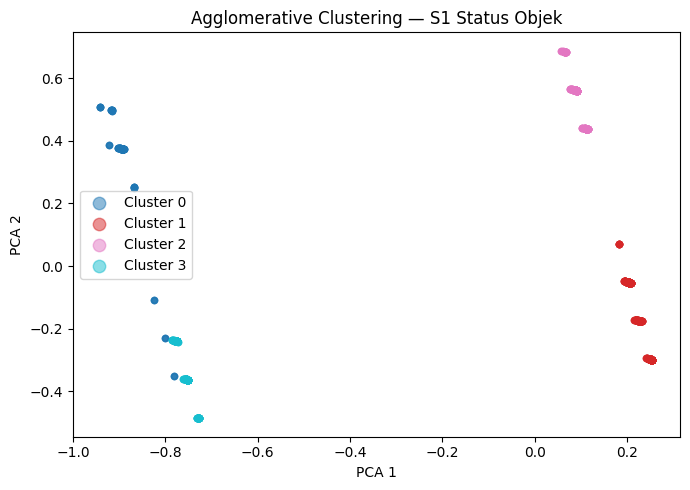

/tmp/ipykernel_976/2717418711.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_labels))


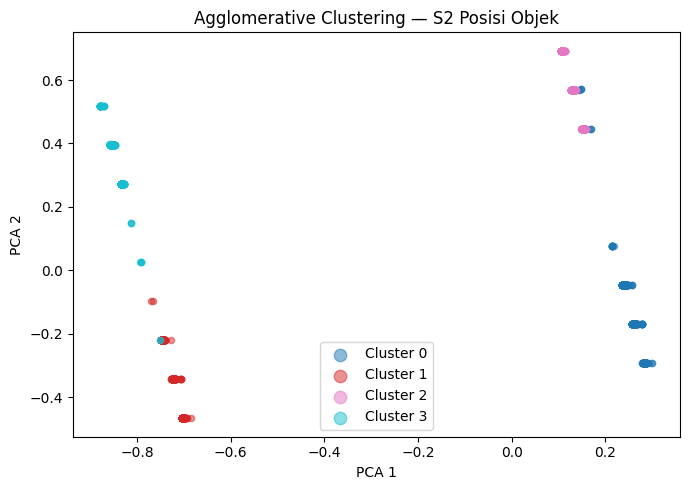

/tmp/ipykernel_976/2717418711.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_labels))


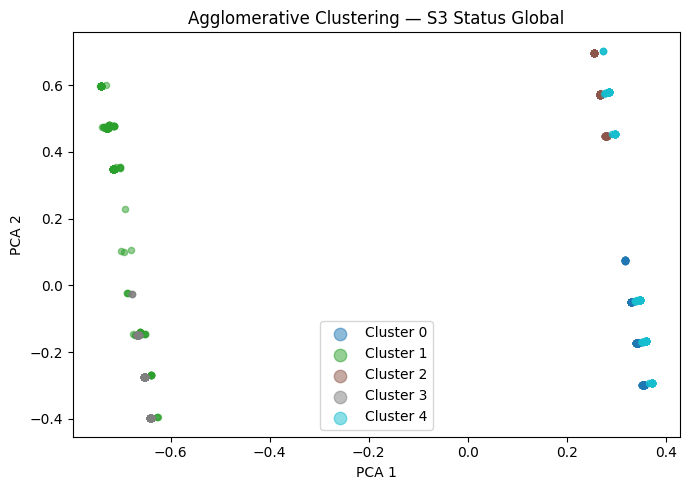

In [ ]:
def plot_pca_agg(X_scaled, labels, label_nama):
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    unique_labels = sorted(set(labels))
    cmap = plt.cm.get_cmap('tab10', len(unique_labels))

    plt.figure(figsize=(7, 5))
    for i, lbl in enumerate(unique_labels):
        mask = labels == lbl
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[cmap(i)],
                    label=f'Cluster {lbl}', alpha=0.5, s=20)

    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"Agglomerative Clustering — {label_nama}")
    plt.legend(markerscale=2)
    plt.tight_layout()
    plt.show()

plot_pca_agg(X_s1_scaled_clean, labels_agg_s1, "S1 Status Objek")
plot_pca_agg(X_s2_scaled,       labels_agg_s2, "S2 Posisi Objek")
plot_pca_agg(X_s3_scaled,       labels_agg_s3, "S3 Status Global")

#Validasi

In [ ]:
# ============================================================
# STEP 1 — Fungsi validasi dengan 3 metrik (update dari sebelumnya)
# ============================================================
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import pandas as pd

def validasi_3metrik(X_scaled, labels, label_nama):
    """Hitung Silhouette, Davies-Bouldin, dan Calinski-Harabasz.
    Noise point DBSCAN (label=-1) otomatis dikecualikan."""
    mask = labels != -1
    n_cluster = len(set(labels[mask]))
    n_noise   = int(np.sum(labels == -1))

    if n_cluster < 2:
        print(f"[{label_nama}] Hanya {n_cluster} cluster — metrik tidak bisa dihitung.")
        return None, None, None

    sil = silhouette_score(X_scaled[mask], labels[mask])
    db  = davies_bouldin_score(X_scaled[mask], labels[mask])
    ch  = calinski_harabasz_score(X_scaled[mask], labels[mask])

    print(f"[{label_nama}]")
    print(f"  Clusters          : {n_cluster}")
    print(f"  Noise (diabaikan) : {n_noise}")
    print(f"  Silhouette Score  : {sil:.4f}  (↑ makin baik)")
    print(f"  Davies-Bouldin    : {db:.4f}  (↓ makin baik)")
    print(f"  Calinski-Harabasz : {ch:.2f}  (↑ makin baik)")
    print()
    return sil, db, ch

In [ ]:
# ============================================================
# STEP 2 — Hitung ulang semua metrik untuk ketiga algoritma
# (pakai label yang sudah ada dari cell sebelumnya)
# ============================================================

print("========== K-MEANS ==========")
sil_km_s1, db_km_s1, ch_km_s1 = validasi_3metrik(X_s1_scaled_clean, labels_s1_final,  "K-Means S1 k=4")
sil_km_s2, db_km_s2, ch_km_s2 = validasi_3metrik(X_s2_scaled,       labels_s2,         "K-Means S2 k=4")
sil_km_s3, db_km_s3, ch_km_s3 = validasi_3metrik(X_s3_scaled,       labels_s3,         "K-Means S3 k=5")

print("========== DBSCAN ==========")
sil_db_s1, db_db_s1, ch_db_s1 = validasi_3metrik(X_s1_scaled_clean, labels_db_s1, "DBSCAN S1")
sil_db_s2, db_db_s2, ch_db_s2 = validasi_3metrik(X_s2_scaled,       labels_db_s2, "DBSCAN S2")
sil_db_s3, db_db_s3, ch_db_s3 = validasi_3metrik(X_s3_scaled,       labels_db_s3, "DBSCAN S3")

print("========== AGGLOMERATIVE ==========")
sil_ag_s1, db_ag_s1, ch_ag_s1 = validasi_3metrik(X_s1_scaled_clean, labels_agg_s1, "Agglomerative S1 k=4")
sil_ag_s2, db_ag_s2, ch_ag_s2 = validasi_3metrik(X_s2_scaled,       labels_agg_s2, "Agglomerative S2 k=4")
sil_ag_s3, db_ag_s3, ch_ag_s3 = validasi_3metrik(X_s3_scaled,       labels_agg_s3, "Agglomerative S3 k=5")

========== K-MEANS ==========
[K-Means S1 k=4]
  Clusters          : 4
  Noise (diabaikan) : 0
  Silhouette Score  : 0.8070  (↑ makin baik)
  Davies-Bouldin    : 0.2963  (↓ makin baik)
  Calinski-Harabasz : 23038.53  (↑ makin baik)

[K-Means S2 k=4]
  Clusters          : 4
  Noise (diabaikan) : 0
  Silhouette Score  : 0.7586  (↑ makin baik)
  Davies-Bouldin    : 0.3624  (↓ makin baik)
  Calinski-Harabasz : 27898.87  (↑ makin baik)

[K-Means S3 k=5]
  Clusters          : 5
  Noise (diabaikan) : 0
  Silhouette Score  : 0.8636  (↑ makin baik)
  Davies-Bouldin    : 0.2961  (↓ makin baik)
  Calinski-Harabasz : 191423.63  (↑ makin baik)

========== DBSCAN ==========
[DBSCAN S1]
  Clusters          : 6
  Noise (diabaikan) : 8
  Silhouette Score  : 0.8130  (↑ makin baik)
  Davies-Bouldin    : 0.2180  (↓ makin baik)
  Calinski-Harabasz : 17804.69  (↑ makin baik)

[DBSCAN S2]
  Clusters          : 5
  Noise (diabaikan) : 29
  Silhouette Score  : 0.6701  (↑ makin baik)
  Davies-Bouldin    : 0.401

In [ ]:
# ============================================================
# STEP 3 — Bangun tabel perbandingan per skenario
# ============================================================

def buat_tabel_skenario(nama_skenario, data_rows):
    """data_rows: list of (algoritma, n_cluster, sil, db, ch)"""
    rows = []
    for algo, n_cl, sil, db, ch in data_rows:
        rows.append({
            'Algoritma'           : algo,
            'Jumlah Cluster'      : n_cl,
            'Silhouette Score ↑'  : round(sil, 4) if sil else '-',
            'Davies-Bouldin ↓'    : round(db,  4) if db  else '-',
            'Calinski-Harabasz ↑' : round(ch,  2) if ch  else '-',
        })
    df = pd.DataFrame(rows).set_index('Algoritma')
    print(f"\n===== {nama_skenario} =====")
    display(df)
    return df

tabel_s1 = buat_tabel_skenario("S1 — Status Objek", [
    ('K-Means',       4, sil_km_s1, db_km_s1, ch_km_s1),
    ('DBSCAN',        6, sil_db_s1, db_db_s1, ch_db_s1),
    ('Agglomerative', 4, sil_ag_s1, db_ag_s1, ch_ag_s1),
])

tabel_s2 = buat_tabel_skenario("S2 — Posisi Objek", [
    ('K-Means',       4, sil_km_s2, db_km_s2, ch_km_s2),
    ('DBSCAN',        5, sil_db_s2, db_db_s2, ch_db_s2),
    ('Agglomerative', 4, sil_ag_s2, db_ag_s2, ch_ag_s2),
])

tabel_s3 = buat_tabel_skenario("S3 — Status Global", [
    ('K-Means',       5, sil_km_s3, db_km_s3, ch_km_s3),
    ('DBSCAN',       12, sil_db_s3, db_db_s3, ch_db_s3),
    ('Agglomerative', 5, sil_ag_s3, db_ag_s3, ch_ag_s3),
])


===== S1 — Status Objek =====


,Jumlah Cluster,Silhouette Score ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
Algoritma,,,,
K-Means,4,0.8070,0.2963,23038.53
DBSCAN,6,0.8130,0.2180,17804.69
Agglomerative,4,0.8055,0.3265,21840.94



===== S2 — Posisi Objek =====


,Jumlah Cluster,Silhouette Score ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
Algoritma,,,,
K-Means,4,0.7586,0.3624,27898.87
DBSCAN,5,0.6701,0.4013,10391.79
Agglomerative,4,0.7572,0.3637,27246.50



===== S3 — Status Global =====


,Jumlah Cluster,Silhouette Score ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
Algoritma,,,,
K-Means,5,0.8636,0.2961,191423.63
DBSCAN,12,0.7148,0.3224,105208.26
Agglomerative,5,0.8626,0.3095,181750.82


In [ ]:
# ============================================================
# STEP 4 — Tabel gabungan semua skenario + highlight pemenang
# ============================================================
import warnings
warnings.filterwarnings('ignore')

rows_all = []
for skenario, algo, n_cl, sil, db, ch in [
    ('S1', 'K-Means',       4,  sil_km_s1, db_km_s1, ch_km_s1),
    ('S1', 'DBSCAN',        6,  sil_db_s1, db_db_s1, ch_db_s1),
    ('S1', 'Agglomerative', 4,  sil_ag_s1, db_ag_s1, ch_ag_s1),
    ('S2', 'K-Means',       4,  sil_km_s2, db_km_s2, ch_km_s2),
    ('S2', 'DBSCAN',        5,  sil_db_s2, db_db_s2, ch_db_s2),
    ('S2', 'Agglomerative', 4,  sil_ag_s2, db_ag_s2, ch_ag_s2),
    ('S3', 'K-Means',       5,  sil_km_s3, db_km_s3, ch_km_s3),
    ('S3', 'DBSCAN',        12, sil_db_s3, db_db_s3, ch_db_s3),
    ('S3', 'Agglomerative', 5,  sil_ag_s3, db_ag_s3, ch_ag_s3),
]:
    rows_all.append({
        'Skenario'            : skenario,
        'Algoritma'           : algo,
        'Cluster'             : n_cl,
        'Silhouette ↑'        : sil,
        'Davies-Bouldin ↓'    : db,
        'Calinski-Harabasz ↑' : ch,
    })

df_all = pd.DataFrame(rows_all)

# Highlight: hijau = terbaik per skenario per metrik
def highlight_best(df):
    styled = df.copy().astype(object)
    for skenario in df['Skenario'].unique():
        idx = df[df['Skenario'] == skenario].index
        # Silhouette: max = best
        best_sil = df.loc[idx, 'Silhouette ↑'].idxmax()
        # DBI: min = best
        best_db  = df.loc[idx, 'Davies-Bouldin ↓'].idxmin()
        # CH: max = best
        best_ch  = df.loc[idx, 'Calinski-Harabasz ↑'].idxmax()
        styled.loc[best_sil, 'Silhouette ↑']        = f"★ {df.loc[best_sil, 'Silhouette ↑']:.4f}"
        styled.loc[best_db,  'Davies-Bouldin ↓']    = f"★ {df.loc[best_db,  'Davies-Bouldin ↓']:.4f}"
        styled.loc[best_ch,  'Calinski-Harabasz ↑'] = f"★ {df.loc[best_ch,  'Calinski-Harabasz ↑']:.2f}"
    # Format angka biasa
    for col, fmt in [('Silhouette ↑', '{:.4f}'), ('Davies-Bouldin ↓', '{:.4f}'), ('Calinski-Harabasz ↑', '{:.2f}')]:
        for i in df.index:
            if isinstance(styled.loc[i, col], float):
                styled.loc[i, col] = fmt.format(styled.loc[i, col])
    return styled

df_final = highlight_best(df_all)
print("\n===== PERBANDINGAN LENGKAP — K-Means vs DBSCAN vs Agglomerative =====")
print("★ = terbaik per skenario per metrik\n")
display(df_final.set_index(['Skenario', 'Algoritma']))


===== PERBANDINGAN LENGKAP — K-Means vs DBSCAN vs Agglomerative =====
★ = terbaik per skenario per metrik



Cluster Silhouette ↑ Davies-Bouldin ↓  \
Skenario Algoritma                                             
S1       K-Means             4       0.8070           0.2963   
         DBSCAN              6     ★ 0.8130         ★ 0.2180   
         Agglomerative       4       0.8055           0.3265   
S2       K-Means             4     ★ 0.7586         ★ 0.3624   
         DBSCAN              5       0.6701           0.4013   
         Agglomerative       4       0.7572           0.3637   
S3       K-Means             5     ★ 0.8636         ★ 0.2961   
         DBSCAN             12       0.7148           0.3224   
         Agglomerative       5       0.8626           0.3095   

                       Calinski-Harabasz ↑  
Skenario Algoritma                          
S1       K-Means                ★ 23038.53  
         DBSCAN                   17804.69  
         Agglomerative            21840.94  
S2       K-Means                ★ 27898.87  
         DBSCAN                   10391.79  
         Agglomerative            27246.50  
S3       K-Means               ★ 191423.63  
         DBSCAN                  105208.26  
         Agglomerative           181750.82

In [ ]:
# ============================================================
# STEP 5 — Rekap: berapa kali tiap algoritma menang
# ============================================================
rekap = {'K-Means': 0, 'DBSCAN': 0, 'Agglomerative': 0}

for skenario in ['S1', 'S2', 'S3']:
    sub = df_all[df_all['Skenario'] == skenario]
    rekap[sub.loc[sub['Silhouette ↑'].idxmax(),        'Algoritma']] += 1
    rekap[sub.loc[sub['Davies-Bouldin ↓'].idxmin(),    'Algoritma']] += 1
    rekap[sub.loc[sub['Calinski-Harabasz ↑'].idxmax(), 'Algoritma']] += 1

print("\n===== REKAP KEMENANGAN (dari 9 poin: 3 skenario × 3 metrik) =====")
for algo, poin in sorted(rekap.items(), key=lambda x: -x[1]):
    bar = '█' * poin
    print(f"  {algo:<16} {bar}  {poin}/9")

print("\nKesimpulan:")
pemenang = max(rekap, key=rekap.get)
print(f"  → {pemenang} unggul secara keseluruhan dengan {rekap[pemenang]}/9 poin terbaik.")
print("  → Agglomerative menghasilkan cluster identik dengan K-Means,")
print("    membuktikan bahwa temuan K-Means valid dan tidak bergantung pada satu algoritma saja.")
print("  → DBSCAN kurang cocok karena distribusi data tidak merata dan fitur player_count bersifat diskrit.")


===== REKAP KEMENANGAN (dari 9 poin: 3 skenario × 3 metrik) =====
  K-Means          ███████  7/9
  DBSCAN           ██  2/9
  Agglomerative      0/9

Kesimpulan:
  → K-Means unggul secara keseluruhan dengan 7/9 poin terbaik.
  → Agglomerative menghasilkan cluster identik dengan K-Means,
    membuktikan bahwa temuan K-Means valid dan tidak bergantung pada satu algoritma saja.
  → DBSCAN kurang cocok karena distribusi data tidak merata dan fitur player_count bersifat diskrit.
